In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

In [ ]:
import os
os.environ["FLAGS_use_mkldnn"] = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = ""  # force CPU, no OneDNN on GPU path

In [ ]:
# !pip install uv

In [ ]:
# # 1. Install uv for faster package management
# !pip install uv

# # 2. Install PaddlePaddle for CPU
# # Note the change in URL from 'cu130' to 'cpu'
# !uv pip install --system -U paddlepaddle -i https://www.paddlepaddle.org.cn/packages/stable/cpu/

# # 3. Install PaddleOCR and standard dependencies
# !uv pip install --system -U "paddleocr[all]" ultralytics lmdb shapely scikit-image pyclipper \
#     rapidfuzz opencv-python opencv-contrib-python cython "Pillow==10.4.0" \
#     pyyaml requests albumentations albucore packaging

# # 4. Install ML frameworks (CPU versions)
# # By default, uv/pip will fetch CPU versions if no GPU is detected,
# # but pinning versions ensures compatibility with your specific OCR requirements.
# !uv pip install --system -U "huggingface_hub<0.24.0" "transformers==4.40.2" "Pillow==10.4.0" \
#     sentencepiece torch torchvision "numpy<2.1.0"

In [ ]:

# !uv pip install --system -U --force-reinstall "numpy==1.26.4" "scipy==1.11.4"

In [ ]:
# !cp -r "/content/drive/MyDrive/Phase3_test/Images" /content/
!cp -r "/content/drive/MyDrive/Colab Notebooks/Macathon/Table Extraction/Phase3" /content/

In [ ]:
import os
import glob
import json
from ultralytics import YOLO

## Data Paths

In [ ]:
# Yolo_Weights="/content/drive/MyDrive/phase 3 submission/The Parsers/Phase 3 Weights/TD_YOLO26_weights/weights/best.pt"
# TSR_Weights="microsoft/table-transformer-structure-recognition-v1.1-all"
# OCR_Weights="/content/drive/MyDrive/phase 3 submission/The Parsers/Phase 2 Weights/test_data/trocr-finetuned-v2/"
# Images_Path="/content/Images/*.jpg"

Yolo_Weights="/content/drive/MyDrive/Colab Notebooks/Macathon/The Parsers/Phase 3 Weights/TD_YOLO26_weights/weights/best.pt"
TSR_Weights="microsoft/table-transformer-structure-recognition-v1.1-all"
OCR_Weights="/content/drive/MyDrive/Colab Notebooks/Macathon/The Parsers/Phase 2 Weights/test_data/trocr-finetuned-v2/"
Images_Path="/content/Images/*.jpg"

In [ ]:
# def pipeline(Data_path,Yolo_Weights,TSR_Weights):

# def validate_weights_path(self,weights):
#     if weights is None:
#       raise ValueError("Weights cannot be None")

#     if not os.path.exists(weights):
#       raise FileNotFoundError(f"Weights file not found: {weights}")

#     return weights

In [ ]:
import gdown
from abc import ABC, abstractmethod

class abstract_class(ABC):
  def __init__(self, url):
    # self.local_path = ""
    # print(self.local_path) # Commenting this out as local_path might not be set yet
    self.weights = url

    self.model = self.get_model()

  def download_model(self, url):
    if not os.path.exists(os.path.dirname(self.local_path)):
      os.makedirs(os.path.dirname(self.local_path), exist_ok=True)
      print(f"Downloading model from {url} to {os.path.dirname(self.local_path)}")
      gdown.download(url, self.local_path , quiet=False)


  @abstractmethod
  def get_model(self):
    pass


## Yolo Class

In [ ]:
class Yolo(abstract_class):
  def __init__(self, weights):
    self.local_path = "/content/weights/Yolo"
    super().__init__(weights)

  def predict(self, image):
    try:
        results_list = self.model(image, conf=0.75)

        # Ensure results_list is not empty before accessing results_list[0]
        if not results_list:
            return {"bbox": [], "bbox_xyxy": [], "crops": []}

        result = results_list[0]

        crops = []
        int_boxes = []

        # Check if result.boxes exists and has data before iterating
        if result.boxes is not None and len(result.boxes.xyxy) > 0:
            for box in result.boxes.xyxy:
                x1, y1, x2, y2 = map(int, box.tolist())
                crops.append(result.orig_img[y1:y2, x1:x2])
                int_boxes.append([x1, y1, x2, y2])

            # Convert bbox to list for JSON compatibility if it's a tensor
            bbox_xywh_list = result.boxes.xywh.tolist() if hasattr(result.boxes, 'xywh') else []

            return {
                "bbox": bbox_xywh_list,
                "bbox_xyxy": int_boxes,
                "crops": crops
            }
        else: # No boxes detected in the image result
            return {"bbox": [], "bbox_xyxy": [], "crops": []}
    except Exception as e:
        print(f"Yolo prediction error for image {image}: {e}")
        return {"bbox": [], "bbox_xyxy": [], "crops": []} # Return empty dict on error

  def get_model(self):
    return YOLO(self.weights)


## TSR Class

In [ ]:
from transformers import TableTransformerForObjectDetection
import torch
import torch.nn.functional as F
from torchvision import transforms
import numpy as np
from PIL import Image

class TSR(abstract_class):
    def __init__(self, TSR_weights=None):
        self.local_path = "/content/weights/TSR/"
        self.device = "cuda" if torch.cuda.is_available() else "cpu"

        # Native PyTorch normalization constants
        self.image_mean = [0.485, 0.456, 0.406]
        self.image_std = [0.229, 0.224, 0.225]

        # Standard Resize bounds for TATR DETR
        self.min_size = 800
        self.max_size = 1333

        super().__init__(TSR_weights)

        if self.model:
            self.model.to(self.device)
            self.model.eval()

    def get_model(self):
        # Workaround: the published v1.1 config has `dilation: null`, but newer
        # huggingface_hub uses strict-dataclass validation that rejects None
        # for the bool-typed field. Patch the dict before constructing the config.
        try:
            from huggingface_hub import hf_hub_download
            from transformers import TableTransformerConfig
            import json as _json
            cfg_path = hf_hub_download(repo_id=TSR_Weights, filename="config.json")
            with open(cfg_path) as _f:
                cfg = _json.load(_f)
            if cfg.get("dilation") is None:
                cfg["dilation"] = False
            return TableTransformerForObjectDetection.from_pretrained(
                TSR_Weights, config=TableTransformerConfig(**cfg)
            )
        except Exception:
            return TableTransformerForObjectDetection.from_pretrained(TSR_Weights)


    def _preprocess_image(self, image):
        """
        Replicates the internal logic of AutoImageProcessor symmetrically.
        - Scales image while maintaining aspect ratio (shortest edge to min_size).
        - Normalizes using standard ImageNet mean/std.
        - Returns unpadded dense pixel constraints.
        """
        w, h = image.size

        # Determine scaling factors
        scale = self.min_size / min(w, h)
        if max(w, h) * scale > self.max_size:
            scale = self.max_size / max(w, h)

        new_w = int(w * scale)
        new_h = int(h * scale)

        # Apply standard Transforms
        transform = transforms.Compose([
            transforms.Resize((new_h, new_w)),
            transforms.ToTensor(),
            transforms.Normalize(mean=self.image_mean, std=self.image_std)
        ])

        # Create final pixel values tensor formatted for batch size constraints.
        pixel_values = transform(image).unsqueeze(0).to(self.device)
        return pixel_values

    def _post_process_bboxes(self, out_logits, out_bbox, target_size, threshold):
        """
        Replicates reverse Bounding Box mapping decoder from DETR ratios back onto the raw input resolution.
        """
        prob = F.softmax(out_logits, -1)
        scores, labels = prob[..., :-1].max(-1)

        # Decode center coordinates to absolute corner edges
        boxes = out_bbox.clone()
        x_c, y_c, w, h = boxes.unbind(-1)
        b = [(x_c - 0.5 * w), (y_c - 0.5 * h), (x_c + 0.5 * w), (y_c + 0.5 * h)]
        boxes = torch.stack(b, dim=-1)

        # Scale back to original resolution constraints
        img_w, img_h = target_size
        scale_fct = torch.tensor([img_w, img_h, img_w, img_h], dtype=torch.float32).to(self.device)
        boxes = boxes * scale_fct[None, :]

        # Threshold filter mask matching Microsoft decoder logic
        keep = scores > threshold
        return scores[keep].cpu().tolist(), labels[keep].cpu().tolist(), boxes[keep].cpu().tolist()

    def _get_intersection(self, box1, box2):
        x1 = max(box1[0], box2[0])
        y1 = max(box1[1], box2[1])
        x2 = min(box1[2], box2[2])
        y2 = min(box1[3], box2[3])
        if x1 < x2 and y1 < y2:
            return [x1, y1, x2, y2]
        return None

    def _calculate_overlap_ratio(self, box1, box2):
        inter = self._get_intersection(box1, box2)
        if not inter:
            return 0.0
        inter_area = (inter[2] - inter[0]) * (inter[3] - inter[1])
        box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
        return inter_area / box1_area if box1_area > 0 else 0.0

    def predict(self, yolo_result, threshold=0.5):
        if not hasattr(yolo_result, 'get') or 'crops' not in yolo_result:
            print("Invalid YOLO result format. Expected a dict with 'bbox' and 'crops'.")
            return []

        table_crops = yolo_result['crops']
        table_bboxes = yolo_result['bbox_xyxy']

        if isinstance(table_bboxes, torch.Tensor):
            table_bboxes = table_bboxes.cpu().tolist()

        tables_output = []

        for table_idx, (crop, t_bbox) in enumerate(zip(table_crops, table_bboxes)):
            # Convert NumPy array to PIL image if needed
            if isinstance(crop, np.ndarray):
                image = Image.fromarray(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)).convert("RGB")
            else:
                image = crop.convert("RGB") if hasattr(crop, "convert") else crop

            w, h = image.size

            with torch.no_grad():
                pixel_values = self._preprocess_image(image)
                outputs = self.model(pixel_values=pixel_values)

                scores, labels, boxes = self._post_process_bboxes(
                    out_logits=outputs.logits[0],
                    out_bbox=outputs.pred_boxes[0],
                    target_size=(w, h),
                    threshold=threshold
                )

            # 1: 'table column', 2: 'table row', 5: 'table spanning cell'
            rows = [box for label, box in zip(labels, boxes) if label == 2]
            columns = [box for label, box in zip(labels, boxes) if label == 1]
            spanning_cells = [box for label, box in zip(labels, boxes) if label == 5 or label==4]

            rows = sorted(rows, key=lambda b: b[1])
            columns = sorted(columns, key=lambda b: b[0])

            final_cells = []
            spanning_cell_intersections = [[] for _ in spanning_cells]

            # Calculate Intersections Map
            for row_idx, row in enumerate(rows):
                for col_idx, col in enumerate(columns):
                    intersect = self._get_intersection(row, col)
                    if intersect:
                        assigned_to_spanning = False
                        for span_idx, span in enumerate(spanning_cells):
                            if self._calculate_overlap_ratio(intersect, span) > 0.5:
                                assigned_to_spanning = True
                                spanning_cell_intersections[span_idx].append((row_idx, col_idx))
                                break

                        if not assigned_to_spanning:
                            final_cells.append({
                                "bbox": intersect,
                                "row": row_idx,
                                "col": col_idx,
                                "rowspan": 1,
                                "colspan": 1,
                            })

            # Process Complex Spans
            for span_idx, span in enumerate(spanning_cells):
                intersections = spanning_cell_intersections[span_idx]
                if intersections:
                    r_indices = [r for r, c in intersections]
                    c_indices = [c for r, c in intersections]

                    final_cells.append({
                        "bbox": span,
                        "row": min(r_indices),
                        "col": min(c_indices),
                        "rowspan": max(r_indices) - min(r_indices) + 1,
                        "colspan": max(c_indices) - min(c_indices) + 1,
                    })

            # Convert xywh to xyxy for the parent table bounding box
            # x_c, y_c, tb_w, tb_h = t_bbox
            # x1 = x_c - tb_w / 2
            # y1 = y_c - tb_h / 2
            # x2 = x_c + tb_w / 2
            # y2 = y_c + tb_h / 2

            x1, y1, x2, y2 = t_bbox

            # 🛠️ THE FIX: Shift every cell's coordinate back to the main image space
            for cell in final_cells:
                cx1, cy1, cx2, cy2 = cell["bbox"]
                # Add the table's absolute top-left (x1, y1) to the cell's relative coordinates
                cell["bbox"] = [cx1 + x1, cy1 + y1, cx2 + x1, cy2 + y1]

            table_entry = {
                "table_id": table_idx,
                "bbox": [x1, y1, x2, y2],
                "cells": final_cells
            }
            tables_output.append(table_entry)

        return tables_output

## PaddleOCR Class

In [ ]:
from paddleocr import PaddleOCR
import cv2
import numpy as np

class DetailedOCR:
    def __init__(self):
        self.model = PaddleOCR(
            use_doc_orientation_classify=False,
            use_doc_unwarping=False,
            use_textline_orientation=False,
            lang='en',
            enable_mkldnn=False,  # paddle 3.3 PIR + oneDNN crashes on CPU
        )
        self.MIN_SIDE = 32   # px — crops smaller than this are upscaled
        self.SCALE    = 2.5  # upscale factor for small crops

    # This predict method now returns detailed OCR results (text and bbox_xyxy)
    # Bounding boxes are relative to the input crop_bgr
    def predict(self, crop_bgr: np.ndarray):
        if crop_bgr is None or crop_bgr.size == 0:
            return [] # Return empty list if no crop

        # 1. BGR → RGB
        crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)

        # 2. Upscale tiny crops
        h, w = crop_rgb.shape[:2]
        scale_x, scale_y = 1.0, 1.0

        if h < self.MIN_SIDE or w < self.MIN_SIDE:
            new_w, new_h = max(w, self.MIN_SIDE), max(h, self.MIN_SIDE)
            crop_rgb = cv2.resize(
                crop_rgb,
                (new_w, new_h),
                interpolation=cv2.INTER_CUBIC
            )
            scale_x = new_w / w
            scale_y = new_h / h
        elif h < 64 or w < 64:
            new_w, new_h = int(w * self.SCALE), int(h * self.SCALE)
            crop_rgb = cv2.resize(
                crop_rgb,
                (new_w, new_h),
                interpolation=cv2.INTER_CUBIC
            )
            scale_x = new_w / w
            scale_y = new_h / h

        # 3. Run OCR
        try:
            # Using .ocr instead of .predict as it is the standard interface that handles arrays robustly
            raw_results = self.model.ocr(crop_rgb, cls=False)
        except Exception as e:
            print(f"OCR predict error: {e}")
            return []

        # 4. Parse PaddleOCR v5 result format to get text and bbox_xyxy
        parsed_results = []
        if raw_results:
            # The `ocr` method returns a list of results, one per image/page.
            # We're processing a single crop (acting as a single image here).
            for res in raw_results:
                if res is None: continue
                # Check for modern object format
                if hasattr(res, 'rec_texts') and hasattr(res, 'rec_polys'):
                    for text, poly in zip(res.rec_texts, res.rec_polys):
                        if text and poly is not None: # Ensure text and polygon are valid
                            # Convert poly (list of 4 [x,y] points) to bounding box (x1, y1, x2, y2)
                            poly_np = np.array(poly).astype(float)
                            x_coords = poly_np[:, 0]
                            y_coords = poly_np[:, 1]

                            # Safely descale the coordinates back to pure original space!
                            x1 = np.min(x_coords) / scale_x
                            y1 = np.min(y_coords) / scale_y
                            x2 = np.max(x_coords) / scale_x
                            y2 = np.max(y_coords) / scale_y

                            parsed_results.append({'text': text, 'bbox_xyxy': [x1, y1, x2, y2]})
                # Check for legacy array format: [[[poly_points], ('text', conf)], ...]
                elif isinstance(res, list):
                    for line in res:
                        if isinstance(line, list) and len(line) == 2:
                            poly = line[0]
                            text_conf = line[1]
                            if isinstance(text_conf, tuple) or isinstance(text_conf, list):
                                text = text_conf[0]
                                if text and poly is not None:
                                    poly_np = np.array(poly).astype(float)
                                    x_coords = poly_np[:, 0]
                                    y_coords = poly_np[:, 1]

                                    x1 = np.min(x_coords) / scale_x
                                    y1 = np.min(y_coords) / scale_y
                                    x2 = np.max(x_coords) / scale_x
                                    y2 = np.max(y_coords) / scale_y

                                    parsed_results.append({'text': text, 'bbox_xyxy': [x1, y1, x2, y2]})
        return parsed_results

# Table processor

In [ ]:
import os
import glob
import json
import cv2
import torch
import gc
import paddle
import numpy as np
import copy
from tqdm.notebook import tqdm


class TableProcessor:
    def __init__(self, yolo_weights, tsr_weights):
        self.yolo = Yolo(yolo_weights)
        self.TSR  = TSR(tsr_weights)
        self.OCR  = DetailedOCR()

    def _calculate_1d_overlap(self, min1, max1, min2, max2):
        """Calculate overlap ratio in 1D."""
        overlap = max(0, min(max1, max2) - max(min1, min2))
        len1 = max1 - min1
        return overlap / (len1 + 1e-6)

    def _calculate_iou(self, boxA, boxB):
        xA = max(boxA[0], boxB[0])
        yA = max(boxA[1], boxB[1])
        xB = min(boxA[2], boxB[2])
        yB = min(boxA[3], boxB[3])

        interArea = max(0, xB - xA) * max(0, yB - yA)
        boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
        boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

        iou = interArea / float(boxAArea + boxBArea - interArea + 1e-6) if boxAArea + boxBArea - interArea > 0 else 0.0
        return iou

    def refine_table_structure(self, tsr_cells, ocr_detections):
        """
        Refines TSR cells using OCR bounding boxes.
        Ensures OCR texts are mapped 1:1 with the best fitting cell, and expands
        cell coordinates if the text physically exceeds the cell limits.
        If an OCR box completely misses TSR cells, it logically infers its position
        and adds it as a new spanning/standard cell.
        """
        refined_cells = []
        working_cells = copy.deepcopy(tsr_cells)

        # Keep track of texts assigned to cells to establish 1:1 matches
        cell_text_map = {i: [] for i in range(len(working_cells))}
        unassigned_ocr = []

        for ocr_det in ocr_detections:
            ocr_box = ocr_det['bbox_xyxy']
            best_cell_idx = -1
            best_overlap = 0

            # Find the best matching cell for this OCR box
            for i, cell in enumerate(working_cells):
                cell_box = cell['bbox']

                xA = max(ocr_box[0], cell_box[0])
                yA = max(ocr_box[1], cell_box[1])
                xB = min(ocr_box[2], cell_box[2])
                yB = min(ocr_box[3], cell_box[3])

                interArea = max(0, xB - xA) * max(0, yB - yA)
                ocrArea = (ocr_box[2] - ocr_box[0]) * (ocr_box[3] - ocr_box[1])

                # We use inclusion ratio specifically focused on OCR box coverage
                inclusion_ratio = interArea / (ocrArea + 1e-6)

                if inclusion_ratio > best_overlap and inclusion_ratio > 0.1: # 10% overlap threshold
                    best_overlap = inclusion_ratio
                    best_cell_idx = i

            # If a match was found, assign text and adjust cell geometry accordingly
            if best_cell_idx != -1:
                cell_text_map[best_cell_idx].append((ocr_det['text'], ocr_box))

                # REVERTED: Do NOT forcefully reshape the TSR cells to OCR bounding boxes.
                # OCR bounding boxes are often sloppy (text height is shorter/longer than the grid cell).
                # Stretching it visually destroys the neat Table-Transformer bounding box grids.
                # The text is securely matched logically within the true cell margins!
            else:
                unassigned_ocr.append(ocr_det)

        # Compute Row/Col Intervals from existing TSR cells to infer missing cells
        row_intervals = {}
        col_intervals = {}
        for cell in working_cells:
            r = cell.get('row')
            c = cell.get('col')
            if r is not None and c is not None:
                box = cell['bbox']
                if r not in row_intervals: row_intervals[r] = [box[1], box[3]]
                else:
                    row_intervals[r][0] = min(row_intervals[r][0], box[1])
                    row_intervals[r][1] = max(row_intervals[r][1], box[3])

                if c not in col_intervals: col_intervals[c] = [box[0], box[2]]
                else:
                    col_intervals[c][0] = min(col_intervals[c][0], box[0])
                    col_intervals[c][1] = max(col_intervals[c][1], box[2])

        # Process each cell into finalizing output
        for i, cell in enumerate(working_cells):
            assigned = cell_text_map[i]
            # Format text natively ordered by spatial properties
            assigned.sort(key=lambda x: (x[1][1], x[1][0])) # Top-down left-right structural match

            joined_text = " ".join([item[0] for item in assigned])
            cell['text'] = joined_text.strip()

            refined_cells.append(cell)

        # Handle unassigned OCR text by creating new cells
        for ocr_det in unassigned_ocr:
            box = ocr_det['bbox_xyxy']

            # Infer logical row(s) and col(s) based on 1D overlap
            matched_rows = []
            for r, (y1, y2) in row_intervals.items():
                if self._calculate_1d_overlap(box[1], box[3], y1, y2) > 0.1: # 10% vertical overlap
                     matched_rows.append(r)

            matched_cols = []
            for c, (x1, x2) in col_intervals.items():
                if self._calculate_1d_overlap(box[0], box[2], x1, x2) > 0.1: # 10% horizontal overlap
                     matched_cols.append(c)

            # Fallback for completely outside text (assign to nearest row)
            if not matched_rows:
                if not row_intervals: matched_rows = [0]
                else:
                    closest_r = min(row_intervals.keys(), key=lambda r: min(abs(box[1]-row_intervals[r][1]), abs(box[3]-row_intervals[r][0])))
                    matched_rows = [closest_r]

            # Fallback for completely outside text (assign to nearest col)
            if not matched_cols:
                if not col_intervals: matched_cols = [0]
                else:
                    closest_c = min(col_intervals.keys(), key=lambda c: min(abs(box[0]-col_intervals[c][1]), abs(box[2]-col_intervals[c][0])))
                    matched_cols = [closest_c]

            # Determine exact structural params
            target_row = min(matched_rows)
            rowspan = max(matched_rows) - target_row + 1
            target_col = min(matched_cols)
            colspan = max(matched_cols) - target_col + 1

            refined_cells.append({
                'bbox': box,
                'row': target_row,
                'col': target_col,
                'rowspan': rowspan,
                'colspan': colspan,
                'text': ocr_det['text']
            })

        return refined_cells

    def predict(self, image_input_path, output_path="/content/processed_tables.json"):
        all_outputs = []
        search_pattern = os.path.join(image_input_path, "*.jpg") if os.path.isdir(image_input_path) else image_input_path
        all_files = sorted(glob.glob(search_pattern))[:100]

        if os.path.exists(output_path):
            with open(output_path, "r") as f:
                all_outputs = json.load(f)
            done_filenames = {entry["filename"] for entry in all_outputs}
            print(f"↪ Resuming: {len(done_filenames)}/{len(all_files)} images already processed.")
        else:
            all_outputs = []
            done_filenames = set()

        for filename in tqdm(all_files, desc="Processing Images"):
            base = os.path.basename(filename)

            if base in done_filenames:
                continue

            image = cv2.imread(filename)
            if image is None:
                print(f"Skipping {base}: Could not read image.")
                continue

            image_results = {"filename": base, "tables": []}

            try:
                # 1. YOLO Detection
                yolo_results = self.yolo.predict(filename)

                for table_idx, (table_crop_bgr, yolo_table_bbox_abs) in enumerate(zip(yolo_results['crops'], yolo_results['bbox_xyxy'])):
                    if table_crop_bgr is None or table_crop_bgr.size == 0:
                        continue

                    # 2. TSR cell mapping prediction
                    tsr_yolo_input = {'crops': [table_crop_bgr], 'bbox_xyxy': [yolo_table_bbox_abs]}
                    tsr_tables_output = self.TSR.predict(tsr_yolo_input)

                    if not tsr_tables_output:
                        continue

                    current_tsr_table = tsr_tables_output[0]

                    # Conform formatting
                    if isinstance(current_tsr_table.get("bbox"), torch.Tensor):
                        current_tsr_table["bbox"] = current_tsr_table["bbox"].cpu().tolist()
                    for cell in current_tsr_table.get('cells', []):
                        if isinstance(cell.get("bbox"), torch.Tensor):
                            cell["bbox"] = cell["bbox"].cpu().tolist()

                    # 3. Complete OCR Detection (Outputs text sequences mapped w/ bounds)
                    ocr_detections_relative = self.OCR.predict(table_crop_bgr)

                    # Align OCR bounds relative mathematically to raw scale
                    ocr_detections_absolute = []
                    tx1_abs, ty1_abs = yolo_table_bbox_abs[0], yolo_table_bbox_abs[1]
                    for ocr_det in ocr_detections_relative:
                        ox1, oy1, ox2, oy2 = ocr_det['bbox_xyxy']
                        ocr_detections_absolute.append({
                            'text': ocr_det['text'],
                            'bbox_xyxy': [ox1 + tx1_abs, oy1 + ty1_abs, ox2 + tx1_abs, oy2 + ty1_abs]
                        })

                    # 4. Integrate both coordinate sources (TSR cell boundaries + OCR textual bounds)
                    refined_cells = self.refine_table_structure(
                        current_tsr_table.get('cells', []),
                        ocr_detections_absolute
                    )

                    current_tsr_table['cells'] = refined_cells
                    image_results["tables"].append(current_tsr_table)

                all_outputs.append(image_results)

                # Persist outputs structurally
                with open(output_path, "w") as f:
                    json.dump(all_outputs, f, indent=4)

            except Exception as e:
                print(f"⚠ Skipping {base} due to error: {e}")

            finally:
                del image
                (torch.cuda.empty_cache() if torch.cuda.is_available() else None)
                (paddle.device.cuda.empty_cache() if paddle.device.is_compiled_with_cuda() else None)
                gc.collect()

        return all_outputs

## Ignore this Error no text in json

In [ ]:
# import os
# import cv2
# import matplotlib.pyplot as plt
# image_dir = "/content/Images"
# image_path = [os.path.join(image_dir, image) for image in os.listdir(image_dir)]

# # 1. Initialize the TableProcessor
# processor = TableProcessor(Yolo_Weights, TSR_Weights)

# # 2. Run the prediction directly on a single image (e.g., your first test image)
# # Note: Ensure `image_path` variable is still properly defined from your previous cells.
# for image in image_path[:100]:
#     test_image_url = image
#     print(f"Running extraction on: {test_image_url}")

#     # This will save output to "sample_output.json" and return the structured object
#     outputs = processor.predict(test_image_url, output_path="sample_output.json")

# print("Processing complete!")

## Submission

In [ ]:
!cp -r /content/Phase3/ /content/newData

In [ ]:
# !pip install kaggle

# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json

In [ ]:
metadata = {
  "title": "table-extraction-dataset",
  "id": "ahmedhusseinelshahat/table-extraction-dataset",
  "licenses": [
    {
      "name": "CC0-1.0"
    }
  ]
}

with open("/content/newData/dataset-metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

In [ ]:
# !kaggle datasets create -p /content/newData -r zip

In [ ]:
# import gdown
# from abc import ABC, abstractmethod

# class abstract_class(ABC):
#     def __init__(self, url):
#         self.weights = url
#         self.model = self.get_model()

#     def download_model(self, url):
#         if not os.path.exists(os.path.dirname(self.local_path)):
#             os.makedirs(os.path.dirname(self.local_path), exist_ok=True)
#             print(f"Downloading model from {url} to {os.path.dirname(self.local_path)}")
#             gdown.download(url, self.local_path, quiet=False)

#     @abstractmethod
#     def get_model(self):
#         pass


# class Yolo(abstract_class):
#     def __init__(self, weights):
#         self.local_path = "/content/weights/Yolo"
#         super().__init__(weights)

#     def predict(self, image):
#         try:
#             results_list = self.model(image, conf=0.75)

#             if not results_list:
#                 return {"bbox": [], "bbox_xyxy": [], "crops": []}

#             result = results_list[0]

#             crops = []
#             int_boxes = []

#             if result.boxes is not None and len(result.boxes.xyxy) > 0:
#                 for box in result.boxes.xyxy:
#                     x1, y1, x2, y2 = map(int, box.tolist())
#                     crops.append(result.orig_img[y1:y2, x1:x2])
#                     int_boxes.append([x1, y1, x2, y2])

#                 bbox_xywh_list = result.boxes.xywh.tolist() if hasattr(result.boxes, 'xywh') else []

#                 return {
#                     "bbox": bbox_xywh_list,
#                     "bbox_xyxy": int_boxes,
#                     "crops": crops
#                 }
#             else:
#                 return {"bbox": [], "bbox_xyxy": [], "crops": []}

#         except Exception as e:
#             return {"bbox": [], "bbox_xyxy": [], "crops": []}

#     def get_model(self):
#         return YOLO(self.weights)


# from transformers import TableTransformerForObjectDetection
# import torch
# import torch.nn.functional as F
# from torchvision import transforms
# import numpy as np
# from PIL import Image


# class TSR(abstract_class):
#     def __init__(self, TSR_weights=None):
#         self.local_path = "/content/weights/TSR/"
#         self.device = "cuda" if torch.cuda.is_available() else "cpu"

#         self.image_mean = [0.485, 0.456, 0.406]
#         self.image_std  = [0.229, 0.224, 0.225]

#         self.min_size = 800
#         self.max_size = 1333

#         super().__init__(TSR_weights)

#         if self.model:
#             self.model.to(self.device)
#             self.model.eval()

#     def get_model(self):
#         return TableTransformerForObjectDetection.from_pretrained(TSR_Weights)

#     def _preprocess_image(self, image):
#         w, h = image.size

#         scale = self.min_size / min(w, h)
#         if max(w, h) * scale > self.max_size:
#             scale = self.max_size / max(w, h)

#         new_w = int(w * scale)
#         new_h = int(h * scale)

#         transform = transforms.Compose([
#             transforms.Resize((new_h, new_w)),
#             transforms.ToTensor(),
#             transforms.Normalize(mean=self.image_mean, std=self.image_std)
#         ])

#         pixel_values = transform(image).unsqueeze(0).to(self.device)
#         return pixel_values

#     def _post_process_bboxes(self, out_logits, out_bbox, target_size, threshold):
#         prob = F.softmax(out_logits, -1)
#         scores, labels = prob[..., :-1].max(-1)

#         boxes = out_bbox.clone()
#         x_c, y_c, w, h = boxes.unbind(-1)
#         b = [(x_c - 0.5 * w), (y_c - 0.5 * h), (x_c + 0.5 * w), (y_c + 0.5 * h)]
#         boxes = torch.stack(b, dim=-1)

#         img_w, img_h = target_size
#         scale_fct = torch.tensor([img_w, img_h, img_w, img_h], dtype=torch.float32).to(self.device)
#         boxes = boxes * scale_fct[None, :]

#         keep = scores > threshold
#         return scores[keep].cpu().tolist(), labels[keep].cpu().tolist(), boxes[keep].cpu().tolist()

#     def _get_intersection(self, box1, box2):
#         x1 = max(box1[0], box2[0])
#         y1 = max(box1[1], box2[1])
#         x2 = min(box1[2], box2[2])
#         y2 = min(box1[3], box2[3])
#         if x1 < x2 and y1 < y2:
#             return [x1, y1, x2, y2]
#         return None

#     def _calculate_overlap_ratio(self, box1, box2):
#         inter = self._get_intersection(box1, box2)
#         if not inter:
#             return 0.0
#         inter_area = (inter[2] - inter[0]) * (inter[3] - inter[1])
#         box1_area  = (box1[2] - box1[0]) * (box1[3] - box1[1])
#         return inter_area / box1_area if box1_area > 0 else 0.0

#     def predict(self, yolo_result, threshold=0.5):
#         if not hasattr(yolo_result, 'get') or 'crops' not in yolo_result:
#             return []

#         table_crops  = yolo_result['crops']
#         table_bboxes = yolo_result['bbox_xyxy']

#         if isinstance(table_bboxes, torch.Tensor):
#             table_bboxes = table_bboxes.cpu().tolist()

#         tables_output = []

#         for table_idx, (crop, t_bbox) in enumerate(zip(table_crops, table_bboxes)):
#             if isinstance(crop, np.ndarray):
#                 image = Image.fromarray(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)).convert("RGB")
#             else:
#                 image = crop.convert("RGB") if hasattr(crop, "convert") else crop

#             w, h = image.size

#             with torch.no_grad():
#                 pixel_values = self._preprocess_image(image)
#                 outputs      = self.model(pixel_values=pixel_values)

#                 scores, labels, boxes = self._post_process_bboxes(
#                     out_logits=outputs.logits[0],
#                     out_bbox=outputs.pred_boxes[0],
#                     target_size=(w, h),
#                     threshold=threshold
#                 )

#             # Free tensors immediately after use
#             del pixel_values, outputs

#             rows          = [box for label, box in zip(labels, boxes) if label == 2]
#             columns       = [box for label, box in zip(labels, boxes) if label == 1]
#             spanning_cells = [box for label, box in zip(labels, boxes) if label == 5 or label == 4]

#             rows    = sorted(rows,    key=lambda b: b[1])
#             columns = sorted(columns, key=lambda b: b[0])

#             final_cells                 = []
#             spanning_cell_intersections = [[] for _ in spanning_cells]

#             for row_idx, row in enumerate(rows):
#                 for col_idx, col in enumerate(columns):
#                     intersect = self._get_intersection(row, col)
#                     if intersect:
#                         assigned_to_spanning = False
#                         for span_idx, span in enumerate(spanning_cells):
#                             if self._calculate_overlap_ratio(intersect, span) > 0.5:
#                                 assigned_to_spanning = True
#                                 spanning_cell_intersections[span_idx].append((row_idx, col_idx))
#                                 break

#                         if not assigned_to_spanning:
#                             final_cells.append({
#                                 "bbox":    intersect,
#                                 "row":     row_idx,
#                                 "col":     col_idx,
#                                 "rowspan": 1,
#                                 "colspan": 1,
#                             })

#             for span_idx, span in enumerate(spanning_cells):
#                 intersections = spanning_cell_intersections[span_idx]
#                 if intersections:
#                     r_indices = [r for r, c in intersections]
#                     c_indices = [c for r, c in intersections]

#                     final_cells.append({
#                         "bbox":    span,
#                         "row":     min(r_indices),
#                         "col":     min(c_indices),
#                         "rowspan": max(r_indices) - min(r_indices) + 1,
#                         "colspan": max(c_indices) - min(c_indices) + 1,
#                     })

#             x1, y1, x2, y2 = t_bbox

#             for cell in final_cells:
#                 cx1, cy1, cx2, cy2 = cell["bbox"]
#                 cell["bbox"] = [cx1 + x1, cy1 + y1, cx2 + x1, cy2 + y1]

#             tables_output.append({
#                 "table_id": table_idx,
#                 "bbox":     [x1, y1, x2, y2],
#                 "cells":    final_cells
#             })

#         return tables_output


# from paddleocr import PaddleOCR
# import cv2
# import numpy as np


# class DetailedOCR:
#     def __init__(self):
#         self.model = PaddleOCR(
#             use_doc_orientation_classify=False,
#             use_doc_unwarping=False,
#             use_textline_orientation=False,
#             lang='en'
#         )
#         self.MIN_SIDE = 32
#         self.SCALE    = 2.5

#     def predict(self, crop_bgr: np.ndarray):
#         if crop_bgr is None or crop_bgr.size == 0:
#             return []

#         crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)

#         h, w       = crop_rgb.shape[:2]
#         scale_x, scale_y = 1.0, 1.0

#         if h < self.MIN_SIDE or w < self.MIN_SIDE:
#             new_w, new_h = max(w, self.MIN_SIDE), max(h, self.MIN_SIDE)
#             crop_rgb = cv2.resize(crop_rgb, (new_w, new_h), interpolation=cv2.INTER_CUBIC)
#             scale_x  = new_w / w
#             scale_y  = new_h / h
#         elif h < 64 or w < 64:
#             new_w, new_h = int(w * self.SCALE), int(h * self.SCALE)
#             crop_rgb = cv2.resize(crop_rgb, (new_w, new_h), interpolation=cv2.INTER_CUBIC)
#             scale_x  = new_w / w
#             scale_y  = new_h / h

#         try:
#             if hasattr(self.model, 'predict'):
#                 raw_results = self.model.predict(crop_rgb)
#             else:
#                 raw_results = self.model.ocr(crop_rgb)
#         except Exception as e:
#             import traceback
#             traceback.print_exc()
#             return []

#         def _poly_to_xyxy(poly, sx, sy):
#             arr = np.asarray(poly, dtype=float)
#             if arr.ndim == 2 and arr.shape[1] == 2:
#                 xs, ys = arr[:, 0], arr[:, 1]
#             elif arr.ndim == 1 and arr.size == 4:
#                 return [arr[0] / sx, arr[1] / sy, arr[2] / sx, arr[3] / sy]
#             else:
#                 return None
#             return [xs.min() / sx, ys.min() / sy, xs.max() / sx, ys.max() / sy]

#         parsed_results = []
#         if raw_results:
#             for res in raw_results:
#                 if res is None:
#                     continue

#                 if isinstance(res, dict) and 'rec_texts' in res:
#                     texts = res.get('rec_texts', [])
#                     polys = res.get('rec_polys') or res.get('rec_boxes') or res.get('dt_polys') or []
#                     for text, poly in zip(texts, polys):
#                         if text and poly is not None:
#                             box = _poly_to_xyxy(poly, scale_x, scale_y)
#                             if box:
#                                 parsed_results.append({'text': text, 'bbox_xyxy': box})

#                 elif hasattr(res, 'rec_texts'):
#                     texts = res.rec_texts
#                     polys = (getattr(res, 'rec_polys', None)
#                              or getattr(res, 'rec_boxes', None)
#                              or getattr(res, 'dt_polys', None) or [])
#                     for text, poly in zip(texts, polys):
#                         if text and poly is not None:
#                             box = _poly_to_xyxy(poly, scale_x, scale_y)
#                             if box:
#                                 parsed_results.append({'text': text, 'bbox_xyxy': box})

#                 elif isinstance(res, list):
#                     for line in res:
#                         if isinstance(line, list) and len(line) == 2:
#                             poly       = line[0]
#                             text_conf  = line[1]
#                             if isinstance(text_conf, (tuple, list)):
#                                 text = text_conf[0]
#                                 if text and poly is not None:
#                                     poly_np  = np.array(poly).astype(float)
#                                     x_coords = poly_np[:, 0]
#                                     y_coords = poly_np[:, 1]
#                                     parsed_results.append({
#                                         'text': text,
#                                         'bbox_xyxy': [
#                                             np.min(x_coords) / scale_x,
#                                             np.min(y_coords) / scale_y,
#                                             np.max(x_coords) / scale_x,
#                                             np.max(y_coords) / scale_y,
#                                         ]
#                                     })

#         return parsed_results


# import os
# import glob
# import json
# import cv2
# import torch
# import gc
# import paddle
# import numpy as np
# import copy
# from tqdm.notebook import tqdm


# class TableProcessor:
#     def __init__(self, yolo_weights, tsr_weights):
#         self.yolo = Yolo(yolo_weights)
#         self.TSR  = TSR(tsr_weights)
#         self.OCR  = DetailedOCR()

#     # ── GPU memory helper ──────────────────────────────────────────────────────
#     def _flush_gpu(self):
#         """Clear both PyTorch and PaddlePaddle CUDA caches + run GC."""
#         torch.cuda.empty_cache()
#         (paddle.device.cuda.empty_cache() if paddle.device.is_compiled_with_cuda() else None)
#         gc.collect()

#     # ── Geometry helpers ───────────────────────────────────────────────────────
#     def _calculate_1d_overlap(self, min1, max1, min2, max2):
#         overlap = max(0, min(max1, max2) - max(min1, min2))
#         len1    = max1 - min1
#         return overlap / (len1 + 1e-6)

#     def _calculate_iou(self, boxA, boxB):
#         xA = max(boxA[0], boxB[0]);  yA = max(boxA[1], boxB[1])
#         xB = min(boxA[2], boxB[2]);  yB = min(boxA[3], boxB[3])
#         interArea = max(0, xB - xA) * max(0, yB - yA)
#         boxAArea  = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
#         boxBArea  = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
#         denom     = boxAArea + boxBArea - interArea + 1e-6
#         return interArea / float(denom) if denom > 0 else 0.0

#     # ── Cell refinement ────────────────────────────────────────────────────────
#     def refine_table_structure(self, tsr_cells, ocr_detections):
#         refined_cells = []
#         working_cells = copy.deepcopy(tsr_cells)

#         cell_text_map  = {i: [] for i in range(len(working_cells))}
#         unassigned_ocr = []

#         for ocr_det in ocr_detections:
#             ocr_box       = ocr_det['bbox_xyxy']
#             best_cell_idx = -1
#             best_overlap  = 0

#             for i, cell in enumerate(working_cells):
#                 cell_box = cell['bbox']

#                 xA = max(ocr_box[0], cell_box[0]);  yA = max(ocr_box[1], cell_box[1])
#                 xB = min(ocr_box[2], cell_box[2]);  yB = min(ocr_box[3], cell_box[3])

#                 interArea       = max(0, xB - xA) * max(0, yB - yA)
#                 ocrArea         = (ocr_box[2] - ocr_box[0]) * (ocr_box[3] - ocr_box[1])
#                 inclusion_ratio = interArea / (ocrArea + 1e-6)

#                 if inclusion_ratio > best_overlap and inclusion_ratio > 0.1:
#                     best_overlap  = inclusion_ratio
#                     best_cell_idx = i

#             if best_cell_idx != -1:
#                 cell_text_map[best_cell_idx].append((ocr_det['text'], ocr_box))
#             else:
#                 unassigned_ocr.append(ocr_det)

#         row_intervals = {}
#         col_intervals = {}
#         for cell in working_cells:
#             r = cell.get('row');  c = cell.get('col')
#             if r is not None and c is not None:
#                 box = cell['bbox']
#                 if r not in row_intervals:
#                     row_intervals[r] = [box[1], box[3]]
#                 else:
#                     row_intervals[r][0] = min(row_intervals[r][0], box[1])
#                     row_intervals[r][1] = max(row_intervals[r][1], box[3])

#                 if c not in col_intervals:
#                     col_intervals[c] = [box[0], box[2]]
#                 else:
#                     col_intervals[c][0] = min(col_intervals[c][0], box[0])
#                     col_intervals[c][1] = max(col_intervals[c][1], box[2])

#         for i, cell in enumerate(working_cells):
#             assigned = cell_text_map[i]
#             assigned.sort(key=lambda x: (x[1][1], x[1][0]))
#             cell['text'] = " ".join([item[0] for item in assigned]).strip()
#             refined_cells.append(cell)

#         for ocr_det in unassigned_ocr:
#             box = ocr_det['bbox_xyxy']

#             matched_rows = [r for r, (y1, y2) in row_intervals.items()
#                             if self._calculate_1d_overlap(box[1], box[3], y1, y2) > 0.1]
#             matched_cols = [c for c, (x1, x2) in col_intervals.items()
#                             if self._calculate_1d_overlap(box[0], box[2], x1, x2) > 0.1]

#             if not matched_rows:
#                 matched_rows = [0] if not row_intervals else [
#                     min(row_intervals.keys(),
#                         key=lambda r: min(abs(box[1] - row_intervals[r][1]),
#                                          abs(box[3] - row_intervals[r][0])))]
#             if not matched_cols:
#                 matched_cols = [0] if not col_intervals else [
#                     min(col_intervals.keys(),
#                         key=lambda c: min(abs(box[0] - col_intervals[c][1]),
#                                          abs(box[2] - col_intervals[c][0])))]

#             target_row = min(matched_rows);  target_col = min(matched_cols)
#             refined_cells.append({
#                 'bbox':    box,
#                 'row':     target_row,
#                 'col':     target_col,
#                 'rowspan': max(matched_rows) - target_row + 1,
#                 'colspan': max(matched_cols) - target_col + 1,
#                 'text':    ocr_det['text']
#             })

#         return refined_cells

#     # ── Main predict loop ──────────────────────────────────────────────────────
#     def predict(self, image_input_path, output_path="/content/processed_tables.json"):
#         search_pattern = (os.path.join(image_input_path, "*.jpg")
#                           if os.path.isdir(image_input_path)
#                           else image_input_path)
#         all_files = sorted(glob.glob(search_pattern))

#         if os.path.exists(output_path):
#             with open(output_path, "r") as f:
#                 all_outputs = json.load(f)
#             done_filenames = {entry["filename"] for entry in all_outputs}
#             print(f"↪ Resuming: {len(done_filenames)}/{len(all_files)} images already processed.")
#         else:
#             all_outputs    = []
#             done_filenames = set()

#         for filename in tqdm(all_files, desc="Processing Images"):
#             base = os.path.basename(filename)
#             if base in done_filenames:
#                 continue

#             image = cv2.imread(filename)
#             if image is None:
#                 print(f"Skipping {base}: Could not read image.")
#                 continue

#             image_results = {"filename": base, "tables": []}

#             try:
#                 # 1. YOLO Detection
#                 yolo_results = self.yolo.predict(filename)
#                 crops  = yolo_results.get('crops', [])
#                 bboxes = yolo_results.get('bbox_xyxy', [])

#                 for table_idx, (table_crop_bgr, yolo_table_bbox_abs) in enumerate(zip(crops, bboxes)):
#                     try:
#                         if table_crop_bgr is None or table_crop_bgr.size == 0:
#                             continue

#                         # 2. TSR
#                         tsr_yolo_input  = {'crops': [table_crop_bgr], 'bbox_xyxy': [yolo_table_bbox_abs]}
#                         tsr_tables_output = self.TSR.predict(tsr_yolo_input)

#                         if not tsr_tables_output:
#                             continue

#                         current_tsr_table = tsr_tables_output[0]
#                         del tsr_tables_output   # free immediately

#                         if isinstance(current_tsr_table.get("bbox"), torch.Tensor):
#                             current_tsr_table["bbox"] = current_tsr_table["bbox"].cpu().tolist()
#                         for cell in current_tsr_table.get('cells', []):
#                             if isinstance(cell.get("bbox"), torch.Tensor):
#                                 cell["bbox"] = cell["bbox"].cpu().tolist()

#                         # 3. OCR
#                         ocr_detections_relative = self.OCR.predict(table_crop_bgr)

#                         tx1_abs, ty1_abs = yolo_table_bbox_abs[0], yolo_table_bbox_abs[1]
#                         ocr_detections_absolute = [
#                             {
#                                 'text': d['text'],
#                                 'bbox_xyxy': [
#                                     d['bbox_xyxy'][0] + tx1_abs,
#                                     d['bbox_xyxy'][1] + ty1_abs,
#                                     d['bbox_xyxy'][2] + tx1_abs,
#                                     d['bbox_xyxy'][3] + ty1_abs,
#                                 ]
#                             }
#                             for d in ocr_detections_relative
#                         ]
#                         del ocr_detections_relative   # free immediately

#                         # 4. Refine
#                         refined_cells = self.refine_table_structure(
#                             current_tsr_table.get('cells', []),
#                             ocr_detections_absolute
#                         )
#                         del ocr_detections_absolute   # free immediately

#                         current_tsr_table['cells'] = refined_cells
#                         image_results["tables"].append(current_tsr_table)

#                     except RuntimeError as e:
#                         if "out of memory" in str(e).lower():
#                             print(f"💥 OOM on {base} table {table_idx} — skipping table")
#                         else:
#                             raise
#                     finally:
#                         self._flush_gpu()   # ← flush after EVERY table

#                 # Free crops — large numpy arrays
#                 del crops, bboxes, yolo_results

#                 all_outputs.append(image_results)

#                 with open(output_path, "w") as f:
#                     json.dump(all_outputs, f, indent=4)

#                 # Keep host RAM lean — disk is the source of truth
#                 if len(all_outputs) > 50:
#                     all_outputs = all_outputs[-10:]

#             except Exception as e:
#                 import traceback
#                 print(f"⚠ Skipping {base}: {type(e).__name__}: {e}")
#                 traceback.print_exc()   # always print so OOM is never silent

#             finally:
#                 del image
#                 self._flush_gpu()   # ← flush after every image too

#         return all_outputs


# # ── Entry point ────────────────────────────────────────────────────────────────
# import os
# image_dir = "/content/images"

# processor = TableProcessor(Yolo_Weights, TSR_Weights)
# outputs   = processor.predict(image_dir, output_path="sample_output.json")

# print("Processing complete!")


# # ── Visualisation ──────────────────────────────────────────────────────────────
# import os
# import json
# import cv2
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.patches as patches
# from tqdm.notebook import tqdm


# def visualize_from_json(
#     json_path: str,
#     images_folder: str,
#     max_images: int = None,
#     figsize_per_table=(28, 7),
# ):
#     if not os.path.exists(json_path):
#         print(f"File {json_path} not found. Please run the prediction cell first.")
#         return

#     with open(json_path, "r") as f:
#         results = json.load(f)

#     if max_images:
#         results = results[:max_images]

#     print(f"Loaded {len(results)} image record(s) from {json_path}\n")

#     for entry in tqdm(results, desc="Visualising", unit="img"):
#         filename = entry["filename"]
#         tables   = entry["tables"]

#         img_path  = os.path.join(images_folder, filename)
#         image_bgr = cv2.imread(img_path)
#         if image_bgr is None:
#             print(f"⚠  Could not read {img_path}, skipping.")
#             continue
#         image_rgb        = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
#         img_h, img_w     = image_bgr.shape[:2]

#         if not tables:
#             fig, ax = plt.subplots(1, 1, figsize=(8, 6))
#             ax.imshow(image_rgb)
#             ax.set_title(f"{filename}\n(no tables detected)", fontsize=11)
#             ax.axis("off")
#             plt.tight_layout()
#             plt.show()
#             continue

#         all_table_bboxes = [t["bbox"] for t in tables if "bbox" in t]
#         colors           = plt.cm.Set1.colors

#         for t_idx, table in enumerate(tables):
#             bbox  = table.get("bbox", [0, 0, img_w, img_h])
#             cells = table.get("cells", [])

#             tx1, ty1, tx2, ty2 = [int(v) for v in bbox]
#             tx1c = max(0, tx1);  ty1c = max(0, ty1)
#             tx2c = min(img_w, tx2);  ty2c = min(img_h, ty2)
#             crop_rgb = image_rgb[ty1c:ty2c, tx1c:tx2c]

#             fig, axes = plt.subplots(1, 4, figsize=figsize_per_table)
#             fig.suptitle(
#                 f"{filename}  —  Table {t_idx}  ({len(cells)} cells)",
#                 fontsize=13, fontweight="bold", y=1.01
#             )

#             # Panel 1: Original
#             axes[0].imshow(image_rgb)
#             axes[0].set_title("Original", fontsize=11)
#             axes[0].axis("off")

#             # Panel 2: Table Detection
#             axes[1].imshow(image_rgb)
#             axes[1].set_title("Table Detection", fontsize=11)
#             axes[1].axis("off")
#             for i, tb in enumerate(all_table_bboxes):
#                 bx1, by1, bx2, by2 = tb
#                 color = colors[i % len(colors)]
#                 axes[1].add_patch(patches.Rectangle(
#                     (bx1, by1), bx2 - bx1, by2 - by1,
#                     linewidth=2, edgecolor=color, facecolor="none"
#                 ))
#                 axes[1].text(
#                     bx1, by1 - 6, f"Table {i}",
#                     color=color, fontsize=9, fontweight="bold",
#                     bbox=dict(facecolor="white", alpha=0.6, pad=2, edgecolor="none")
#                 )

#             # Panel 3: Cell Structure
#             axes[2].imshow(crop_rgb)
#             axes[2].set_title("Cell Structure", fontsize=11)
#             axes[2].axis("off")
#             for cell in cells:
#                 cx1 = cell["bbox"][0] - tx1c;  cy1 = cell["bbox"][1] - ty1c
#                 cx2 = cell["bbox"][2] - tx1c;  cy2 = cell["bbox"][3] - ty1c
#                 is_spanning = cell.get("rowspan", 1) > 1 or cell.get("colspan", 1) > 1
#                 color       = "#E91E63" if is_spanning else "#FF9800"
#                 axes[2].add_patch(patches.Rectangle(
#                     (cx1, cy1), cx2 - cx1, cy2 - cy1,
#                     linewidth=1.5, edgecolor=color, facecolor=color, alpha=0.18
#                 ))
#                 label = f"r{cell.get('row','?')}c{cell.get('col','?')}"
#                 if is_spanning:
#                     label += f"\n({cell.get('rowspan',1)}×{cell.get('colspan',1)})"
#                 axes[2].text(
#                     (cx1 + cx2) / 2, (cy1 + cy2) / 2, label,
#                     ha="center", va="center", fontsize=6,
#                     bbox=dict(facecolor="white", alpha=0.5, pad=1, edgecolor="none")
#                 )
#             axes[2].legend(handles=[
#                 patches.Patch(facecolor="#FF9800", alpha=0.5, label="Normal cell"),
#                 patches.Patch(facecolor="#E91E63", alpha=0.5, label="Spanning cell"),
#             ], loc="upper right", fontsize=7)

#             # Panel 4: OCR Output
#             axes[3].imshow(crop_rgb)
#             axes[3].set_title("OCR Output", fontsize=11)
#             axes[3].axis("off")
#             for cell in cells:
#                 cx1 = cell["bbox"][0] - tx1c;  cy1 = cell["bbox"][1] - ty1c
#                 cx2 = cell["bbox"][2] - tx1c;  cy2 = cell["bbox"][3] - ty1c
#                 cell_w = cx2 - cx1
#                 axes[3].add_patch(patches.Rectangle(
#                     (cx1, cy1), cell_w, cy2 - cy1,
#                     linewidth=1, edgecolor="#333", facecolor="white", alpha=0.3
#                 ))
#                 text     = cell.get("text", "").strip()
#                 max_chars = max(int(cell_w / 6), 3)
#                 display   = text if len(text) <= max_chars else text[:max_chars] + "…"
#                 axes[3].text(
#                     (cx1 + cx2) / 2, (cy1 + cy2) / 2, display,
#                     ha="center", va="center", fontsize=6, color="black",
#                     bbox=dict(
#                         facecolor="lightyellow", alpha=0.7,
#                         pad=1, edgecolor="none", boxstyle="round,pad=0.2"
#                     )
#                 )

#             plt.tight_layout()
#             plt.show()
#             plt.close(fig)   # release memory after each figure


# # ── Usage ──────────────────────────────────────────────────────────────────────
# # visualize_from_json(
# #     json_path     = "sample_output.json",
# #     images_folder = "/content/images",
# #     max_images    = 50
# # )

## Rest not needed

Loaded 20 image record(s) from sample_output.json



Visualising:   0%|          | 0/20 [00:00<?, ?img/s]


📄  000001.jpg  —  1 table(s)


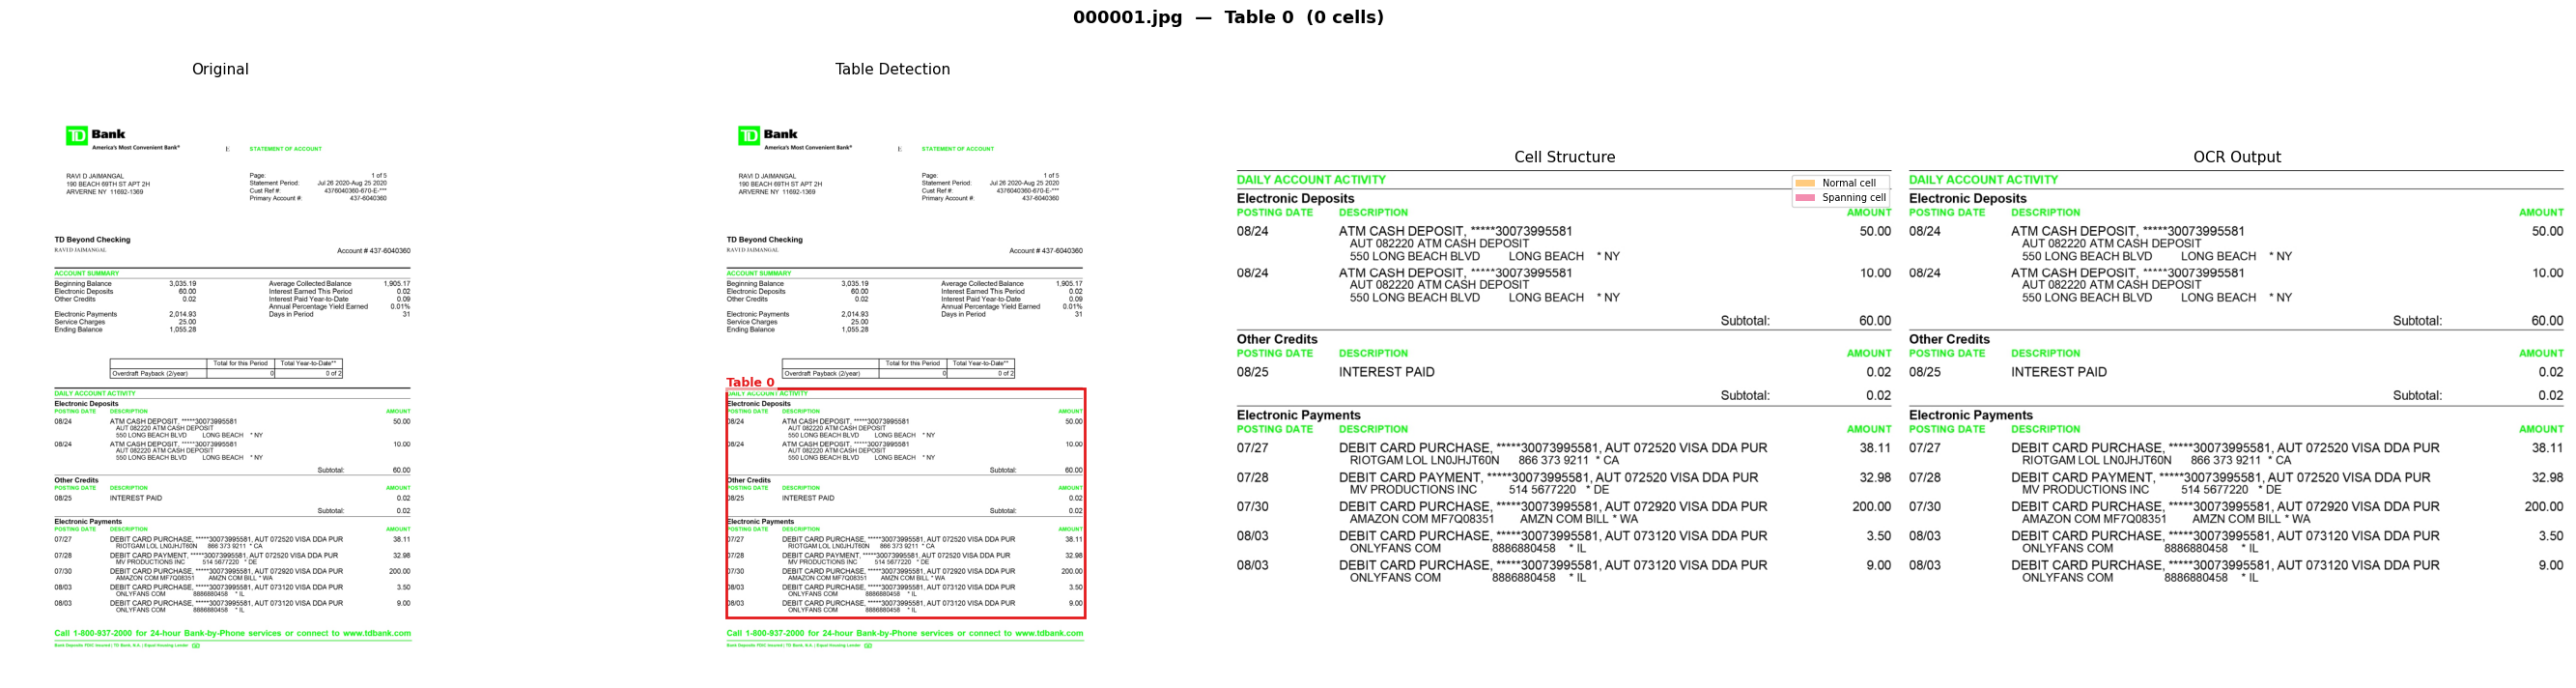


📄  000002.jpg  —  1 table(s)


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/PIL/ImageFile.py", line 547, in _save
    fh = fp.fileno()
         ^^^^^^^^^
AttributeError: '_idat' object has no attribute 'fileno'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_11533/2156207718.py", line 177, in <cell line: 0>
    visualize_from_json(
  File "/tmp/ipykernel_11533/2156207718.py", line 169, in visualize_from_json
    plt.show()
  File "/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py", line 613, in show
    return _get_backend_mod().show(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/matplotlib_inline/backend_inline.py", line 90, in show
    display(
  File "/usr/loca

TypeError: object of type 'NoneType' has no len()

In [ ]:
import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm.notebook import tqdm

def visualize_from_json(
    json_path: str,
    images_folder: str,
    max_images: int = None,        # set to e.g. 5 to preview a subset
    figsize_per_table=(28, 7),
):
    """
    Visualize table extraction results from a pre-dumped JSON file.

    Args:
        json_path      : Path to the JSON produced by pipeline.predict()
        images_folder  : Folder containing the original .jpg images
        max_images     : If set, only visualise the first N images
        figsize_per_table : (width, height) per table figure
    """

    if not os.path.exists(json_path):
        print(f"File {json_path} not found. Please run the prediction cell first.")
        return

    # ── Load JSON ──────────────────────────────────────────────────────────────
    with open(json_path, "r") as f:
        results = json.load(f)

    if max_images:
        results = results[:max_images]

    print(f"Loaded {len(results)} image record(s) from {json_path}\n")

    for entry in tqdm(results, desc="Visualising", unit="img"):
        filename  = entry["filename"]
        tables    = entry["tables"]

        # ── Load image ─────────────────────────────────────────────────────
        img_path = os.path.join(images_folder, filename)
        image_bgr = cv2.imread(img_path)
        if image_bgr is None:
            print(f"⚠  Could not read {img_path}, skipping.")
            continue
        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        img_h, img_w = image_bgr.shape[:2]

        print(f"\n📄  {filename}  —  {len(tables)} table(s)")

        if not tables:
            # Still show the image so you know it was processed
            fig, ax = plt.subplots(1, 1, figsize=(8, 6))
            ax.imshow(image_rgb)
            ax.set_title(f"{filename}\n(no tables detected)", fontsize=11)
            ax.axis("off")
            plt.tight_layout()
            plt.show()
            continue

        # ── Per-table figure ───────────────────────────────────────────────
        # Collect all table bboxes for the YOLO panel
        all_table_bboxes = [t["bbox"] for t in tables if "bbox" in t]
        colors = plt.cm.Set1.colors

        for t_idx, table in enumerate(tables):
            # Table Bounding Box constraints
            bbox   = table.get("bbox", [0, 0, img_w, img_h])
            cells  = table.get("cells", [])

            tx1, ty1, tx2, ty2 = [int(v) for v in bbox]

            # Crop to table region for panels 3 & 4 (ensuring valid dimensions)
            tx1c = max(0, tx1); ty1c = max(0, ty1)
            tx2c = min(img_w, tx2); ty2c = min(img_h, ty2)
            crop_rgb = image_rgb[ty1c:ty2c, tx1c:tx2c]

            fig, axes = plt.subplots(1, 4, figsize=figsize_per_table)
            fig.suptitle(
                f"{filename}  —  Table {t_idx}  "
                f"({len(cells)} cells)",
                fontsize=13, fontweight="bold", y=1.01
            )

            # ── Panel 1: Original ──────────────────────────────────────────
            axes[0].imshow(image_rgb)
            axes[0].set_title("Original", fontsize=11)
            axes[0].axis("off")

            # ── Panel 2: All table detections (YOLO) ──────────────────────
            axes[1].imshow(image_rgb)
            axes[1].set_title("Table Detection", fontsize=11)
            axes[1].axis("off")
            for i, tb in enumerate(all_table_bboxes):
                bx1, by1, bx2, by2 = tb
                color = colors[i % len(colors)]
                axes[1].add_patch(patches.Rectangle(
                    (bx1, by1), bx2 - bx1, by2 - by1,
                    linewidth=2, edgecolor=color, facecolor="none"
                ))
                axes[1].text(
                    bx1, by1 - 6, f"Table {i}",
                    color=color, fontsize=9, fontweight="bold",
                    bbox=dict(facecolor="white", alpha=0.6, pad=2, edgecolor="none")
                )

            # ── Panel 3: Cell structure ────────────────────────────────────
            axes[2].imshow(crop_rgb)
            axes[2].set_title("Cell Structure", fontsize=11)
            axes[2].axis("off")
            for cell in cells:
                # Adjust cell coordinates relative to the crop
                cx1 = cell["bbox"][0] - tx1c
                cy1 = cell["bbox"][1] - ty1c
                cx2 = cell["bbox"][2] - tx1c
                cy2 = cell["bbox"][3] - ty1c

                is_spanning = cell.get("rowspan", 1) > 1 or cell.get("colspan", 1) > 1
                color = "#E91E63" if is_spanning else "#FF9800"
                axes[2].add_patch(patches.Rectangle(
                    (cx1, cy1), cx2 - cx1, cy2 - cy1,
                    linewidth=1.5, edgecolor=color, facecolor=color, alpha=0.18
                ))
                label = f"r{cell.get('row','?')}c{cell.get('col','?')}"
                if is_spanning:
                    label += f"\n({cell.get('rowspan',1)}×{cell.get('colspan',1)})"

                axes[2].text(
                    (cx1 + cx2) / 2, (cy1 + cy2) / 2, label,
                    ha="center", va="center", fontsize=6,
                    bbox=dict(facecolor="white", alpha=0.5, pad=1, edgecolor="none")
                )
            axes[2].legend(handles=[
                patches.Patch(facecolor="#FF9800", alpha=0.5, label="Normal cell"),
                patches.Patch(facecolor="#E91E63", alpha=0.5, label="Spanning cell"),
            ], loc="upper right", fontsize=7)

            # ── Panel 4: OCR overlay ───────────────────────────────────────
            axes[3].imshow(crop_rgb)
            axes[3].set_title("OCR Output", fontsize=11)
            axes[3].axis("off")
            for cell in cells:
                # Adjust cell coordinates relative to the crop
                cx1 = cell["bbox"][0] - tx1c
                cy1 = cell["bbox"][1] - ty1c
                cx2 = cell["bbox"][2] - tx1c
                cy2 = cell["bbox"][3] - ty1c
                cell_w = cx2 - cx1

                axes[3].add_patch(patches.Rectangle(
                    (cx1, cy1), cell_w, cy2 - cy1,
                    linewidth=1, edgecolor="#333", facecolor="white", alpha=0.3
                ))
                text = cell.get("text", "").strip()
                max_chars = max(int(cell_w / 6), 3)
                display = text if len(text) <= max_chars else text[:max_chars] + "…"
                axes[3].text(
                    (cx1 + cx2) / 2, (cy1 + cy2) / 2, display,
                    ha="center", va="center", fontsize=6, color="black",
                    bbox=dict(
                        facecolor="lightyellow", alpha=0.7,
                        pad=1, edgecolor="none", boxstyle="round,pad=0.2"
                    )
                )

            plt.tight_layout()
            plt.show()
            plt.close(fig)   # ← release memory after each figure

    print(f"\n✓ Visualisation complete.")


# ── Usage ──────────────────────────────────────────────────────────────────────
# Note: Ensure that the 'sample_output.json' has been generated by the TableProcessor cell above.
visualize_from_json(
    json_path       = "sample_output.json",
    images_folder   = "/content/Phase3/Images",
    max_images      = 50   # Set to 5 for a quick sanity check first
)

In [ ]:
import json
import numpy as np
from pathlib import Path
from typing import List, Dict, Tuple
from tqdm.notebook import tqdm

class TableEvaluator:
    def __init__(self, pred_json_path: str, gt_json_path: str):
        """
        Initializes the evaluator with predictions and ground truth data.

        Args:
            pred_json_path: Path to the model's output JSON.
            gt_json_path: Path to the Ground Truth JSON (must match pred format).
        """
        self.weights = {
            "teds": 0.5,
            "grits": 0.3,
            "f1": {
                "total": 0.2,
                "table": 0.2,
                "cell": 0.8
            }
        }

        with open(pred_json_path, 'r') as f:
            self.preds = {item['filename']: item for item in json.load(f)}

        with open(gt_json_path, 'r') as f:
            self.gts = {item['filename']: item for item in json.load(f)}

    def calculate_iou(self, boxA: List[float], boxB: List[float]) -> float:
        """Calculates Intersection over Union (IoU) for two bounding boxes."""
        xA = max(boxA[0], boxB[0])
        yA = max(boxA[1], boxB[1])
        xB = min(boxA[2], boxB[2])
        yB = min(boxA[3], boxB[3])

        interArea = max(0, xB - xA) * max(0, yB - yA)
        boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
        boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

        iou = interArea / float(boxAArea + boxBArea - interArea + 1e-6) if (boxAArea + boxBArea - interArea) > 0 else 0.0
        return iou

    def calculate_f1_score(self, pred_boxes: List[List[float]], gt_boxes: List[List[float]], iou_thresh=0.5) -> float:
        """
        Matches predicted boxes to GT boxes via IoU to calculate Precision, Recall, and F1.
        """
        if len(pred_boxes) == 0 and len(gt_boxes) == 0:
            return 1.0
        if len(pred_boxes) == 0 or len(gt_boxes) == 0:
            return 0.0

        matched_gt = set()
        tp = 0

        # Greedy matching
        for p_box in pred_boxes:
            best_iou = 0
            best_gt_idx = -1

            for i, g_box in enumerate(gt_boxes):
                if i in matched_gt:
                    continue
                iou = self.calculate_iou(p_box, g_box)
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = i

            if best_iou >= iou_thresh:
                tp += 1
                matched_gt.add(best_gt_idx)

        fp = len(pred_boxes) - tp
        fn = len(gt_boxes) - tp

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

        if precision + recall == 0:
            return 0.0

        f1 = 2 * (precision * recall) / (precision + recall)
        return f1

    def evaluate_f1(self, pred_tables: List[Dict], gt_tables: List[Dict]) -> Tuple[float, float]:
        """Calculates F1 for Table BBs and Cell BBs for a single image."""
        p_table_boxes = [t.get('bbox', []) for t in pred_tables]
        g_table_boxes = [t.get('bbox', []) for t in gt_tables]

        table_f1 = self.calculate_f1_score(p_table_boxes, g_table_boxes)

        # Collect all cell boxes flat across all tables in the image
        p_cell_boxes = [cell['bbox'] for t in pred_tables for cell in t.get('cells', [])]
        g_cell_boxes = [cell['bbox'] for t in gt_tables for cell in t.get('cells', [])]

        cell_f1 = self.calculate_f1_score(p_cell_boxes, g_cell_boxes)

        return table_f1, cell_f1

    def calculate_teds(self, pred_tables: List[Dict], gt_tables: List[Dict]) -> float:
        """
        Placeholder for TEDS (Tree-Edit-Distance-based Similarity).
        Requires converting bbox/content grids to HTML first, then computing distance.
        """
        # TODO: Implement HTML string conversion & metric logic (using e.g., 'zss' or 'apted' package)
        return 0.85 # Returning dummy score for structure

    def calculate_grits(self, pred_tables: List[Dict], gt_tables: List[Dict]) -> float:
        """
        Placeholder for GriTS (Grid Table Similarity) - Top & Con.
        Requires 2D matrix intersection matching.
        """
        # TODO: Implement 2D adjacency grid matrix matching
        return 0.80 # Returning dummy score for structure

    def evaluate_all(self):
        print("Starting full evaluation...")
        results = []

        # For overall scores
        total_metrics = {'table_f1': [], 'cell_f1': [], 'teds': [], 'grits': []}

        for filename, gt_entry in tqdm(self.gts.items(), desc="Evaluating"):
            pred_entry = self.preds.get(filename, {"tables": []})

            p_tables = pred_entry.get('tables', [])
            g_tables = gt_entry.get('tables', [])

            table_f1, cell_f1 = self.evaluate_f1(p_tables, g_tables)
            teds_score = self.calculate_teds(p_tables, g_tables)
            grits_score = self.calculate_grits(p_tables, g_tables)

            # Aggregate based on weights
            combined_f1 = (self.weights['f1']['table'] * table_f1) + (self.weights['f1']['cell'] * cell_f1)

            final_score = (
                (self.weights['teds'] * teds_score) +
                (self.weights['grits'] * grits_score) +
                (self.weights['f1']['total'] * combined_f1)
            )

            results.append({
                'filename': filename,
                'table_f1': table_f1,
                'cell_f1': cell_f1,
                'teds': teds_score,
                'grits': grits_score,
                'final_weighted_score': final_score
            })

            total_metrics['table_f1'].append(table_f1)
            total_metrics['cell_f1'].append(cell_f1)
            total_metrics['teds'].append(teds_score)
            total_metrics['grits'].append(grits_score)

        # Print Benchmark Report
        print("\n" + "="*40)
        print("📊 EVALUATION BENCHMARK REPORT")
        print("="*40)
        avg_table_f1 = np.mean(total_metrics['table_f1'])
        avg_cell_f1 = np.mean(total_metrics['cell_f1'])
        avg_teds = np.mean(total_metrics['teds'])
        avg_grits = np.mean(total_metrics['grits'])

        avg_combined_f1 = (self.weights['f1']['table'] * avg_table_f1) + (self.weights['f1']['cell'] * avg_cell_f1)

        overall_score = (
            (self.weights['teds'] * avg_teds) +
            (self.weights['grits'] * avg_grits) +
            (self.weights['f1']['total'] * avg_combined_f1)
        )

        print(f"F1-Score Tables (Weight 0.2 of F1) : {avg_table_f1:.4f}")
        print(f"F1-Score Cells (Weight 0.8 of F1)  : {avg_cell_f1:.4f}")
        print(f"Subtotal F1 Score                  : {avg_combined_f1:.4f}")
        print("-" * 40)
        print(f"TEDS Score (Weight 0.5)            : {avg_teds:.4f}")
        print(f"GriTS Score (Weight 0.3)           : {avg_grits:.4f}")
        print("-" * 40)
        print(f"🏆 FINAL METRIC SCORE               : {overall_score:.4f}")
        print("="*40)

        return results

# Usage once Ground Truth is ready:
# evaluator = TableEvaluator(pred_json_path="sample_output.json", gt_json_path="path/to/ground_truth.json")
# final_report = evaluator.evaluate_all()

In [ ]:
import os
import glob
import json
import cv2
import torch
import gc
import paddle
import numpy as np
from tqdm.notebook import tqdm

class TableExtraction:
    def __init__(self, yolo_weights, tsr_weights):
        self.yolo = Yolo(yolo_weights)
        self.TSR  = TSR(tsr_weights)
        self.OCR  = OCR()

    def _safe_ocr(self, crop):
        if crop is None or crop.size == 0:
            return ""
        crop_clean = np.ascontiguousarray(crop)
        try:
            result = self.OCR.predict(crop_clean)
            return result if isinstance(result, str) else ""
        except Exception:
            return ""

    def _cells_to_html(self, cells):
        """Converts logical cell data into an HTML string for TEDS evaluation."""
        if not cells: return "<table></table>"

        # Filter out cells that might be missing structural data
        valid_cells = [c for c in cells if 'row' in c and 'col' in c]
        if not valid_cells: return "<table></table>"

        max_row = max(c['row'] + c.get('rowspan', 1) for c in valid_cells)
        max_col = max(c['col'] + c.get('colspan', 1) for c in valid_cells)

        html = "<table>"
        for r in range(max_row):
            html += "<tr>"
            for c in range(max_col):
                cell = next((item for item in valid_cells if item['row'] == r and item['col'] == c), None)
                if cell:
                    rs = cell.get('rowspan', 1)
                    cs = cell.get('colspan', 1)
                    content = cell.get('text', "")

                    span = ""
                    if rs > 1: span += f' rowspan="{rs}"'
                    if cs > 1: span += f' colspan="{cs}"'
                    html += f"<td{span}>{content}</td>"
            html += "</tr>"
        html += "</table>"
        return html

    def predict(self, image_path, output_path="/content/data_file.json"):
        search_pattern = os.path.join(image_path, "*.jpg") if os.path.isdir(image_path) else image_path
        all_files = sorted(glob.glob(search_pattern))

        # --- RESUME LOGIC ---
        output_dict = {}
        if os.path.exists(output_path):
            with open(output_path, "r") as f:
                output_dict = json.load(f)
            print(f"↪ Resuming: {len(output_dict)}/{len(all_files)} already done.")

        for filename in tqdm(all_files, desc="Images"):
            base = os.path.basename(filename)

            if base in output_dict:
                continue

            image = cv2.imread(filename)
            if image is None:
                continue

            img_h, img_w = image.shape[:2]
            image_results = {"filename": base, "tables": []}

            try:
                # 1. Detection & Structure
                with torch.no_grad():
                    boxes = self.yolo.predict(filename)
                    tsr_output = self.TSR.predict(boxes)

                # 2. Process Cells
                for table in tsr_output:
                    if isinstance(table.get("bbox"), torch.Tensor):
                        table["bbox"] = table["bbox"].cpu().tolist()
                    table.pop("crop", None)
                    table.pop("crops", None)

                    for cell in table.get("cells", []):
                        if isinstance(cell.get("bbox"), torch.Tensor):
                            cell["bbox"] = cell["bbox"].cpu().tolist()

                        x1, y1, x2, y2 = cell["bbox"]
                        ix1, iy1 = max(0, int(x1)), max(0, int(y1))
                        ix2, iy2 = min(img_w, int(x2)), min(img_h, int(y2))

                        if iy2 > iy1 and ix2 > ix1:
                            cropped = image[iy1:iy2, ix1:ix2]
                            cell["text"] = self._safe_ocr(cropped)
                        else:
                            cell["text"] = ""

                    # Inject HTML format needed for local TEDS directly into the table object
                    table["html"] = self._cells_to_html(table.get("cells", []))
                    image_results["tables"].append(table)

                # Save into dictionary mapped by filename
                output_dict[base] = image_results

                # --- SAVE AFTER EVERY IMAGE ---
                with open(output_path, "w") as f:
                    json.dump(output_dict, f, indent=4)

            except Exception as e:
                print(f"⚠ Skipping {base} due to error: {e}")

            finally:
                del image
                (torch.cuda.empty_cache() if torch.cuda.is_available() else None)
                (paddle.device.cuda.empty_cache() if paddle.device.is_compiled_with_cuda() else None)
                gc.collect()

        return output_dict


# ── Inference ──────────────────────────────────────────────────────────────────
OUTPUT_PATH = "/content/data_file.json"

pipeline = TableExtraction(
    yolo_weights=Yolo_Weights,  # Ensure these are defined in your notebook
    tsr_weights=TSR_Weights
)

output_data = pipeline.predict("/content/Images/", output_path=OUTPUT_PATH)
print(f"✓ Done. Ready for local evaluation. Download: {OUTPUT_PATH}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/115M [00:00<?, ?B/s]

NameError: name 'OCR' is not defined

## Macathon Submission

In [ ]:
import gdown
from abc import ABC, abstractmethod

class abstract_class(ABC):
  def __init__(self, url):
    # self.local_path = ""
    # print(self.local_path) # Commenting this out as local_path might not be set yet
    self.weights = url

    self.model = self.get_model()

  def download_model(self, url):
    if not os.path.exists(os.path.dirname(self.local_path)):
      os.makedirs(os.path.dirname(self.local_path), exist_ok=True)
      print(f"Downloading model from {url} to {os.path.dirname(self.local_path)}")
      gdown.download(url, self.local_path , quiet=False)


  @abstractmethod
  def get_model(self):
    pass
class Yolo(abstract_class):
  def __init__(self, weights):
    self.local_path = "/content/weights/Yolo"
    super().__init__(weights)

  def predict(self, image):
    try:
        results_list = self.model(image, conf=0.75)

        # Ensure results_list is not empty before accessing results_list[0]
        if not results_list:
            return {"bbox": [], "bbox_xyxy": [], "crops": []}

        result = results_list[0]

        crops = []
        int_boxes = []

        # Check if result.boxes exists and has data before iterating
        if result.boxes is not None and len(result.boxes.xyxy) > 0:
            for box in result.boxes.xyxy:
                x1, y1, x2, y2 = map(int, box.tolist())
                crops.append(result.orig_img[y1:y2, x1:x2])
                int_boxes.append([x1, y1, x2, y2])

            # Convert bbox to list for JSON compatibility if it's a tensor
            bbox_xywh_list = result.boxes.xywh.tolist() if hasattr(result.boxes, 'xywh') else []

            return {
                "bbox": bbox_xywh_list,
                "bbox_xyxy": int_boxes,
                "crops": crops
            }
        else: # No boxes detected in the image result
            return {"bbox": [], "bbox_xyxy": [], "crops": []}
    except Exception as e:
        print(f"Yolo prediction error for image {image}: {e}")
        return {"bbox": [], "bbox_xyxy": [], "crops": []} # Return empty dict on error

  def get_model(self):
    return YOLO(self.weights)
from transformers import TableTransformerForObjectDetection
import torch
import torch.nn.functional as F
from torchvision import transforms
import numpy as np
from PIL import Image

class TSR(abstract_class):
    def __init__(self, TSR_weights=None):
        self.local_path = "/content/weights/TSR/"
        self.device = "cuda" if torch.cuda.is_available() else "cpu"

        # Native PyTorch normalization constants
        self.image_mean = [0.485, 0.456, 0.406]
        self.image_std = [0.229, 0.224, 0.225]

        # Standard Resize bounds for TATR DETR
        self.min_size = 800
        self.max_size = 1333

        super().__init__(TSR_weights)

        if self.model:
            self.model.to(self.device)
            self.model.eval()

    def get_model(self):
        # Workaround: the published v1.1 config has `dilation: null`, but newer
        # huggingface_hub uses strict-dataclass validation that rejects None
        # for the bool-typed field. Patch the dict before constructing the config.
        try:
            from huggingface_hub import hf_hub_download
            from transformers import TableTransformerConfig
            import json as _json
            cfg_path = hf_hub_download(repo_id=TSR_Weights, filename="config.json")
            with open(cfg_path) as _f:
                cfg = _json.load(_f)
            if cfg.get("dilation") is None:
                cfg["dilation"] = False
            return TableTransformerForObjectDetection.from_pretrained(
                TSR_Weights, config=TableTransformerConfig(**cfg)
            )
        except Exception:
            return TableTransformerForObjectDetection.from_pretrained(TSR_Weights)


    def _preprocess_image(self, image):
        """
        Replicates the internal logic of AutoImageProcessor symmetrically.
        - Scales image while maintaining aspect ratio (shortest edge to min_size).
        - Normalizes using standard ImageNet mean/std.
        - Returns unpadded dense pixel constraints.
        """
        w, h = image.size

        # Determine scaling factors
        scale = self.min_size / min(w, h)
        if max(w, h) * scale > self.max_size:
            scale = self.max_size / max(w, h)

        new_w = int(w * scale)
        new_h = int(h * scale)

        # Apply standard Transforms
        transform = transforms.Compose([
            transforms.Resize((new_h, new_w)),
            transforms.ToTensor(),
            transforms.Normalize(mean=self.image_mean, std=self.image_std)
        ])

        # Create final pixel values tensor formatted for batch size constraints.
        pixel_values = transform(image).unsqueeze(0).to(self.device)
        return pixel_values

    def _post_process_bboxes(self, out_logits, out_bbox, target_size, threshold):
        """
        Replicates reverse Bounding Box mapping decoder from DETR ratios back onto the raw input resolution.
        """
        prob = F.softmax(out_logits, -1)
        scores, labels = prob[..., :-1].max(-1)

        # Decode center coordinates to absolute corner edges
        boxes = out_bbox.clone()
        x_c, y_c, w, h = boxes.unbind(-1)
        b = [(x_c - 0.5 * w), (y_c - 0.5 * h), (x_c + 0.5 * w), (y_c + 0.5 * h)]
        boxes = torch.stack(b, dim=-1)

        # Scale back to original resolution constraints
        img_w, img_h = target_size
        scale_fct = torch.tensor([img_w, img_h, img_w, img_h], dtype=torch.float32).to(self.device)
        boxes = boxes * scale_fct[None, :]

        # Threshold filter mask matching Microsoft decoder logic
        keep = scores > threshold
        return scores[keep].cpu().tolist(), labels[keep].cpu().tolist(), boxes[keep].cpu().tolist()

    def _get_intersection(self, box1, box2):
        x1 = max(box1[0], box2[0])
        y1 = max(box1[1], box2[1])
        x2 = min(box1[2], box2[2])
        y2 = min(box1[3], box2[3])
        if x1 < x2 and y1 < y2:
            return [x1, y1, x2, y2]
        return None

    def _calculate_overlap_ratio(self, box1, box2):
        inter = self._get_intersection(box1, box2)
        if not inter:
            return 0.0
        inter_area = (inter[2] - inter[0]) * (inter[3] - inter[1])
        box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
        return inter_area / box1_area if box1_area > 0 else 0.0

    def predict(self, yolo_result, threshold=0.5):
        if not hasattr(yolo_result, 'get') or 'crops' not in yolo_result:
            print("Invalid YOLO result format. Expected a dict with 'bbox' and 'crops'.")
            return []

        table_crops = yolo_result['crops']
        table_bboxes = yolo_result['bbox_xyxy']

        if isinstance(table_bboxes, torch.Tensor):
            table_bboxes = table_bboxes.cpu().tolist()

        tables_output = []

        for table_idx, (crop, t_bbox) in enumerate(zip(table_crops, table_bboxes)):
            # Convert NumPy array to PIL image if needed
            if isinstance(crop, np.ndarray):
                image = Image.fromarray(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)).convert("RGB")
            else:
                image = crop.convert("RGB") if hasattr(crop, "convert") else crop

            w, h = image.size

            with torch.no_grad():
                pixel_values = self._preprocess_image(image)
                outputs = self.model(pixel_values=pixel_values)

                scores, labels, boxes = self._post_process_bboxes(
                    out_logits=outputs.logits[0],
                    out_bbox=outputs.pred_boxes[0],
                    target_size=(w, h),
                    threshold=threshold
                )

            # 1: 'table column', 2: 'table row', 5: 'table spanning cell'
            rows = [box for label, box in zip(labels, boxes) if label == 2]
            columns = [box for label, box in zip(labels, boxes) if label == 1]
            spanning_cells = [box for label, box in zip(labels, boxes) if label == 5 or label==4]

            rows = sorted(rows, key=lambda b: b[1])
            columns = sorted(columns, key=lambda b: b[0])

            final_cells = []
            spanning_cell_intersections = [[] for _ in spanning_cells]

            # Calculate Intersections Map
            for row_idx, row in enumerate(rows):
                for col_idx, col in enumerate(columns):
                    intersect = self._get_intersection(row, col)
                    if intersect:
                        assigned_to_spanning = False
                        for span_idx, span in enumerate(spanning_cells):
                            if self._calculate_overlap_ratio(intersect, span) > 0.5:
                                assigned_to_spanning = True
                                spanning_cell_intersections[span_idx].append((row_idx, col_idx))
                                break

                        if not assigned_to_spanning:
                            final_cells.append({
                                "bbox": intersect,
                                "row": row_idx,
                                "col": col_idx,
                                "rowspan": 1,
                                "colspan": 1,
                            })

            # Process Complex Spans
            for span_idx, span in enumerate(spanning_cells):
                intersections = spanning_cell_intersections[span_idx]
                if intersections:
                    r_indices = [r for r, c in intersections]
                    c_indices = [c for r, c in intersections]

                    final_cells.append({
                        "bbox": span,
                        "row": min(r_indices),
                        "col": min(c_indices),
                        "rowspan": max(r_indices) - min(r_indices) + 1,
                        "colspan": max(c_indices) - min(c_indices) + 1,
                    })

            # Convert xywh to xyxy for the parent table bounding box
            # x_c, y_c, tb_w, tb_h = t_bbox
            # x1 = x_c - tb_w / 2
            # y1 = y_c - tb_h / 2
            # x2 = x_c + tb_w / 2
            # y2 = y_c + tb_h / 2

            x1, y1, x2, y2 = t_bbox

            # 🛠️ THE FIX: Shift every cell's coordinate back to the main image space
            for cell in final_cells:
                cx1, cy1, cx2, cy2 = cell["bbox"]
                # Add the table's absolute top-left (x1, y1) to the cell's relative coordinates
                cell["bbox"] = [cx1 + x1, cy1 + y1, cx2 + x1, cy2 + y1]

            table_entry = {
                "table_id": table_idx,
                "bbox": [x1, y1, x2, y2],
                "cells": final_cells
            }
            tables_output.append(table_entry)

        return tables_output

from paddleocr import PaddleOCR
import cv2
import numpy as np

class DetailedOCR:
    def __init__(self):
        self.model = PaddleOCR(
            use_doc_orientation_classify=False,
            use_doc_unwarping=False,
            use_textline_orientation=False,
            lang='en',
            enable_mkldnn=False,  # paddle 3.3 PIR + oneDNN crashes on CPU
        )
        self.MIN_SIDE = 32   # px — crops smaller than this are upscaled
        self.SCALE    = 2.5  # upscale factor for small crops
        self.MAX_SIDE = 1920

    # This predict method now returns detailed OCR results (text and bbox_xyxy)
    # Bounding boxes are relative to the input crop_bgr
    def predict(self, crop_bgr: np.ndarray):
        if crop_bgr is None or crop_bgr.size == 0:
            return [] # Return empty list if no crop

        # 1. BGR → RGB
        crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)

        # 2. Upscale tiny crops
        h, w = crop_rgb.shape[:2]
        scale_x, scale_y = 1.0, 1.0

        if h < self.MIN_SIDE or w < self.MIN_SIDE:
            new_w = max(w, self.MIN_SIDE)
            new_h = max(h, self.MIN_SIDE)
            crop_rgb = cv2.resize(crop_rgb, (new_w, new_h), interpolation=cv2.INTER_CUBIC)
            scale_x = new_w / w
            scale_y = new_h / h
        elif h < 64 or w < 64:
            new_w = int(w * self.SCALE)
            new_h = int(h * self.SCALE)
            crop_rgb = cv2.resize(crop_rgb, (new_w, new_h), interpolation=cv2.INTER_CUBIC)
            scale_x = new_w / w
            scale_y = new_h / h
        elif max(h, w) > self.MAX_SIDE:          # ← NEW: downscale oversized crops
            ratio = self.MAX_SIDE / max(h, w)
            new_w = int(w * ratio)
            new_h = int(h * ratio)
            crop_rgb = cv2.resize(crop_rgb, (new_w, new_h), interpolation=cv2.INTER_AREA)
            scale_x = new_w / w
            scale_y = new_h / h

        # 3. Run OCR — use .predict() for PaddleOCR 3.x, fall back to .ocr() for 2.x.
        # `cls=False` was a v2.x kwarg; in 3.x it's set via constructor (use_textline_orientation=False).
        try:
          if hasattr(self.model, 'predict'):
              raw_results = self.model.predict(crop_rgb)
          else:
              raw_results = self.model.ocr(crop_rgb)
        except Exception as e:
          import traceback, paddle, gc
          # Detect paddle/CUDA OOM — paddle raises RuntimeError with "Out of memory"
          if "out of memory" in str(e).lower() or "oom" in str(e).lower():
              print(f"[OCR OOM] Crop shape {crop_rgb.shape} exceeded memory — flushing and skipping.")
              (paddle.device.cuda.empty_cache() if paddle.device.is_compiled_with_cuda() else None)
              gc.collect()
          else:
              print(f"[OCR ERROR] {type(e).__name__}: {e}")
              traceback.print_exc()
          return []

        # 4. Parse PaddleOCR result — handle v2.x list format, v3.x OCRResult object,
        #    and v3.x dict-style results. Also handle both polygon (4,2) and rect (4,) shapes.
        def _poly_to_xyxy(poly, sx, sy):
            arr = np.asarray(poly, dtype=float)
            if arr.ndim == 2 and arr.shape[1] == 2:          # polygon [[x,y],...]
                xs, ys = arr[:, 0], arr[:, 1]
            elif arr.ndim == 1 and arr.size == 4:            # rect [x1,y1,x2,y2]
                return [arr[0] / sx, arr[1] / sy, arr[2] / sx, arr[3] / sy]
            else:
                return None
            return [xs.min() / sx, ys.min() / sy, xs.max() / sx, ys.max() / sy]

        parsed_results = []
        if raw_results:
            first = raw_results[0] if raw_results else None
            print(f"[OCR DEBUG] type(raw)={type(raw_results).__name__} len={len(raw_results)} "
                  f"type(first)={type(first).__name__}")

            for res in raw_results:
                if res is None:
                    continue

                # v3.x: dict-style result (from .predict())
                if isinstance(res, dict) and 'rec_texts' in res:
                    texts = res.get('rec_texts', [])
                    polys = res.get('rec_polys') or res.get('rec_boxes') or res.get('dt_polys') or []
                    for text, poly in zip(texts, polys):
                        if text and poly is not None:
                            box = _poly_to_xyxy(poly, scale_x, scale_y)
                            if box: parsed_results.append({'text': text, 'bbox_xyxy': box})

                # v3.x: OCRResult object with attributes
                elif hasattr(res, 'rec_texts'):
                    texts = res.rec_texts
                    polys = (getattr(res, 'rec_polys', None)
                             or getattr(res, 'rec_boxes', None)
                             or getattr(res, 'dt_polys', None) or [])
                    for text, poly in zip(texts, polys):
                        if text and poly is not None:
                            box = _poly_to_xyxy(poly, scale_x, scale_y)
                            if box: parsed_results.append({'text': text, 'bbox_xyxy': box})

                # v2.x: legacy nested list format
                elif isinstance(res, list):
                    for line in res:
                        if isinstance(line, list) and len(line) == 2:
                            poly = line[0]
                            text_conf = line[1]
                            if isinstance(text_conf, tuple) or isinstance(text_conf, list):
                                text = text_conf[0]
                                if text and poly is not None:
                                    poly_np = np.array(poly).astype(float)
                                    x_coords = poly_np[:, 0]
                                    y_coords = poly_np[:, 1]

                                    x1 = np.min(x_coords) / scale_x
                                    y1 = np.min(y_coords) / scale_y
                                    x2 = np.max(x_coords) / scale_x
                                    y2 = np.max(y_coords) / scale_y

                                    parsed_results.append({'text': text, 'bbox_xyxy': [x1, y1, x2, y2]})

        if not parsed_results:
            print(f"[OCR WARN] 0 texts parsed. raw_results repr: {repr(raw_results)[:100]}")
        return parsed_results

import os
import glob
import json
import cv2
import torch
import gc
import paddle
import numpy as np
import copy
from tqdm.notebook import tqdm


class TableProcessor:
    def __init__(self, yolo_weights, tsr_weights):
        self.yolo = Yolo(yolo_weights)
        self.TSR  = TSR(tsr_weights)
        self.OCR  = DetailedOCR()

    def _calculate_1d_overlap(self, min1, max1, min2, max2):
        """Calculate overlap ratio in 1D."""
        overlap = max(0, min(max1, max2) - max(min1, min2))
        len1 = max1 - min1
        return overlap / (len1 + 1e-6)

    def _calculate_iou(self, boxA, boxB):
        xA = max(boxA[0], boxB[0])
        yA = max(boxA[1], boxB[1])
        xB = min(boxA[2], boxB[2])
        yB = min(boxA[3], boxB[3])

        interArea = max(0, xB - xA) * max(0, yB - yA)
        boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
        boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

        iou = interArea / float(boxAArea + boxBArea - interArea + 1e-6) if boxAArea + boxBArea - interArea > 0 else 0.0
        return iou

    def refine_table_structure(self, tsr_cells, ocr_detections):
      """
      Refines TSR cells using OCR bounding boxes.
      - Merges TSR cells that are bridged by a single OCR box
        (OCR box covers >= 15% of its area in each of 2+ cells).
      - Removes cells that receive no OCR text.
      - Unassigned OCR texts are inferred and added as new cells.
      """

      working_cells = copy.deepcopy(tsr_cells)

      # ── Helper: what fraction of the OCR box overlaps a given cell ──────────
      def ocr_coverage(ocr_box, cell_box):
          xA = max(ocr_box[0], cell_box[0]);  yA = max(ocr_box[1], cell_box[1])
          xB = min(ocr_box[2], cell_box[2]);  yB = min(ocr_box[3], cell_box[3])
          inter    = max(0, xB - xA) * max(0, yB - yA)
          ocr_area = max(1e-6, (ocr_box[2]-ocr_box[0]) * (ocr_box[3]-ocr_box[1]))
          return inter / ocr_area

      # ── Step 1: Assign every OCR detection to its best-matching cell ─────────
      # Identical to your original logic — untouched.
      cell_text_map  = {i: [] for i in range(len(working_cells))}
      unassigned_ocr = []

      for ocr_det in ocr_detections:
          ocr_box      = ocr_det['bbox_xyxy']
          best_idx     = -1
          best_overlap = 0.0

          for i, cell in enumerate(working_cells):
              cell_box = cell['bbox']
              xA = max(ocr_box[0], cell_box[0]);  yA = max(ocr_box[1], cell_box[1])
              xB = min(ocr_box[2], cell_box[2]);  yB = min(ocr_box[3], cell_box[3])
              interArea = max(0, xB - xA) * max(0, yB - yA)
              ocrArea   = max(0, (ocr_box[2]-ocr_box[0])) * max(0, (ocr_box[3]-ocr_box[1]))
              inclusion_ratio = interArea / (ocrArea + 1e-6)

              if inclusion_ratio > best_overlap and inclusion_ratio > 0.1:
                  best_overlap = inclusion_ratio
                  best_idx     = i

          if best_idx != -1:
              cell_text_map[best_idx].append((ocr_det['text'], ocr_box))
          else:
              unassigned_ocr.append(ocr_det)

      # ── Step 2: Find cells to merge (one OCR box bridges 2+ cells) ──────────
      # A cell qualifies for merging only if the OCR box covers >= 15% of
      # the OCR box's own area inside that cell. This prevents edge-touch merges.
      merge_groups = []

      for ocr_det in ocr_detections:
          ocr_box = ocr_det['bbox_xyxy']
          touched = {i for i, cell in enumerate(working_cells)
                    if ocr_coverage(ocr_box, cell['bbox']) >= 0.15}

          if len(touched) < 2:
              continue   # spans only one cell — nothing to merge

          # Union into existing groups that share any member
          absorbed = None
          for g in merge_groups:
              if g & touched:
                  g |= touched
                  absorbed = g
                  break
          if absorbed is None:
              merge_groups.append(set(touched))
          else:
              # Collapse any further groups that now overlap absorbed
              changed = True
              while changed:
                  changed = False
                  for g in merge_groups:
                      if g is not absorbed and g & absorbed:
                          absorbed |= g
                          merge_groups.remove(g)
                          changed = True
                          break

      # ── Step 3: Apply merges ─────────────────────────────────────────────────
      cells_to_skip = set()

      for group in merge_groups:
          rep       = min(group)   # representative = lowest index (topmost-left cell)
          non_reps  = group - {rep}
          cells_to_skip |= non_reps

          # Expand the representative's bbox/span to cover all merged members
          all_boxes = [working_cells[i]['bbox'] for i in group]
          rows      = [working_cells[i]['row']  for i in group]
          cols      = [working_cells[i]['col']  for i in group]

          working_cells[rep]['bbox']    = [
              min(b[0] for b in all_boxes), min(b[1] for b in all_boxes),
              max(b[2] for b in all_boxes), max(b[3] for b in all_boxes),
          ]
          working_cells[rep]['row']     = min(rows)
          working_cells[rep]['col']     = min(cols)
          working_cells[rep]['rowspan'] = max(rows) - min(rows) + 1
          working_cells[rep]['colspan'] = max(cols) - min(cols) + 1

          # Redirect text from absorbed cells into the representative
          for idx in non_reps:
              cell_text_map[rep].extend(cell_text_map.pop(idx, []))

      # ── Step 4: Build refined cells — only drop truly empty ones ────────────
      refined_cells   = []
      row_intervals   = {}
      col_intervals   = {}

      for i, cell in enumerate(working_cells):
          if i in cells_to_skip:
              continue   # absorbed into a merged cell

          assigned = cell_text_map.get(i, [])

          if not assigned:
              continue   # no OCR text — drop this cell

          assigned.sort(key=lambda x: (x[1][1], x[1][0]))   # top-down, left-right
          cell['text'] = " ".join(t for t, _ in assigned).strip()
          refined_cells.append(cell)

          # Build row/col intervals for Step 5 fallback
          r, c  = cell.get('row'), cell.get('col')
          box   = cell['bbox']
          if r is not None:
              if r not in row_intervals:
                  row_intervals[r] = [box[1], box[3]]
              else:
                  row_intervals[r][0] = min(row_intervals[r][0], box[1])
                  row_intervals[r][1] = max(row_intervals[r][1], box[3])
          if c is not None:
              if c not in col_intervals:
                  col_intervals[c] = [box[0], box[2]]
              else:
                  col_intervals[c][0] = min(col_intervals[c][0], box[0])
                  col_intervals[c][1] = max(col_intervals[c][1], box[2])

      # ── Step 5: Unassigned OCR — identical to your original logic ────────────
      for ocr_det in unassigned_ocr:
          box = ocr_det['bbox_xyxy']

          matched_rows = [r for r, (y1, y2) in row_intervals.items()
                          if self._calculate_1d_overlap(box[1], box[3], y1, y2) > 0.1]
          matched_cols = [c for c, (x1, x2) in col_intervals.items()
                          if self._calculate_1d_overlap(box[0], box[2], x1, x2) > 0.1]

          if not matched_rows:
              matched_rows = [min(row_intervals, key=lambda r: min(
                  abs(box[1] - row_intervals[r][1]), abs(box[3] - row_intervals[r][0])
              ))] if row_intervals else [0]

          if not matched_cols:
              matched_cols = [min(col_intervals, key=lambda c: min(
                  abs(box[0] - col_intervals[c][1]), abs(box[2] - col_intervals[c][0])
              ))] if col_intervals else [0]

          target_row = min(matched_rows)
          target_col = min(matched_cols)
          refined_cells.append({
              'bbox':    box,
              'row':     target_row,
              'col':     target_col,
              'rowspan': max(matched_rows) - target_row + 1,
              'colspan': max(matched_cols) - target_col + 1,
              'text':    ocr_det['text'],
          })

      return refined_cells

    def predict(self, image_input_path, output_path="/content/processed_tables.json"):
        all_outputs = []
        search_pattern = os.path.join(image_input_path, "*.jpg") if os.path.isdir(image_input_path) else image_input_path
        all_files = sorted(glob.glob(search_pattern))

        if os.path.exists(output_path):
            with open(output_path, "r") as f:
                all_outputs = json.load(f)
            done_filenames = {entry["filename"] for entry in all_outputs}
            print(f"↪ Resuming: {len(done_filenames)}/{len(all_files)} images already processed.")
        else:
            all_outputs = []
            done_filenames = set()

        for filename in tqdm(all_files, desc="Processing Images"):
            base = os.path.basename(filename)

            if base in done_filenames:
                continue

            image = cv2.imread(filename)
            if image is None:
                print(f"Skipping {base}: Could not read image.")
                continue

            image_results = {"filename": base, "tables": []}

            try:
                # 1. YOLO Detection
                yolo_results = self.yolo.predict(filename)

                for table_idx, (table_crop_bgr, yolo_table_bbox_abs) in enumerate(zip(yolo_results['crops'], yolo_results['bbox_xyxy'])):
                    if table_crop_bgr is None or table_crop_bgr.size == 0:
                        continue

                    # 2. TSR cell mapping prediction
                    tsr_yolo_input = {'crops': [table_crop_bgr], 'bbox_xyxy': [yolo_table_bbox_abs]}
                    tsr_tables_output = self.TSR.predict(tsr_yolo_input)

                    if not tsr_tables_output:
                        continue

                    current_tsr_table = tsr_tables_output[0]

                    # Conform formatting
                    if isinstance(current_tsr_table.get("bbox"), torch.Tensor):
                        current_tsr_table["bbox"] = current_tsr_table["bbox"].cpu().tolist()
                    for cell in current_tsr_table.get('cells', []):
                        if isinstance(cell.get("bbox"), torch.Tensor):
                            cell["bbox"] = cell["bbox"].cpu().tolist()

                    # 3. Complete OCR Detection (Outputs text sequences mapped w/ bounds)
                    ocr_detections_relative = self.OCR.predict(table_crop_bgr)
                    (paddle.device.cuda.empty_cache() if paddle.device.is_compiled_with_cuda() else None)
                    gc.collect()
                    del table_crop_bgr
                    print(f"[PIPELINE] table {table_idx}: {len(current_tsr_table.get('cells', []))} TSR cells, "
                          f"{len(ocr_detections_relative)} OCR texts")

                    # Align OCR bounds relative mathematically to raw scale
                    ocr_detections_absolute = []
                    tx1_abs, ty1_abs = yolo_table_bbox_abs[0], yolo_table_bbox_abs[1]
                    for ocr_det in ocr_detections_relative:
                        ox1, oy1, ox2, oy2 = ocr_det['bbox_xyxy']
                        ocr_detections_absolute.append({
                            'text': ocr_det['text'],
                            'bbox_xyxy': [ox1 + tx1_abs, oy1 + ty1_abs, ox2 + tx1_abs, oy2 + ty1_abs]
                        })

                    # 4. Integrate both coordinate sources (TSR cell boundaries + OCR textual bounds)
                    refined_cells = self.refine_table_structure(
                        current_tsr_table.get('cells', []),
                        ocr_detections_absolute
                    )
                    non_empty = sum(1 for c in refined_cells if c.get('text'))
                    print(f"[PIPELINE] table {table_idx}: {non_empty}/{len(refined_cells)} cells got text")

                    current_tsr_table['cells'] = refined_cells
                    image_results["tables"].append(current_tsr_table)

                all_outputs.append(image_results)

                # Persist outputs structurally
                with open(output_path, "w") as f:
                    json.dump(all_outputs, f, indent=4)

            except Exception as e:
                import traceback
                print(f"⚠ Skipping {base} due to error: {type(e).__name__}: {e}")
                traceback.print_exc()

            finally:
                del image
                torch.cuda.empty_cache()
                (paddle.device.cuda.empty_cache() if paddle.device.is_compiled_with_cuda() else None)
                gc.collect()

        return all_outputs

import os
import cv2
import matplotlib.pyplot as plt
image_path = sorted(glob.glob("/content/Phase3/Images/*.jpg"))

# 1. Initialize the TableProcessor
processor = TableProcessor(Yolo_Weights, TSR_Weights)

# 2. Run the prediction directly on a single image (e.g., your first test image)
# Note: Ensure `image_path` variable is still properly defined from your previous cells.
for image in image_path[:20]:
    test_image_url = image
    print(f"Running extraction on: {test_image_url}")

    # This will save output to "sample_output.json" and return the structured object
    output = processor.predict(test_image_url, output_path="sample_output.json")

print("Processing complete!")

import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm.notebook import tqdm

def visualize_from_json(
    # json_path: str,
    images_folder: str,
    max_images: int = None,        # set to e.g. 5 to preview a subset
    figsize_per_table=(28, 7),
):
    """
    Visualize table extraction results from a pre-dumped JSON file.

    Args:
        json_path      : Path to the JSON produced by pipeline.predict()
        images_folder  : Folder containing the original .jpg images
        max_images     : If set, only visualise the first N images
        figsize_per_table : (width, height) per table figure
    """

    # if not os.path.exists(json_path):
    #     print(f"File {json_path} not found. Please run the prediction cell first.")
    #     return

    # # ── Load JSON ──────────────────────────────────────────────────────────────
    # with open(json_path, "r") as f:
    #     results = json.load(f)

    results = output
    if max_images:
        results = results[:max_images]

    # print(f"Loaded {len(results)} image record(s) from {json_path}\n")

    for entry in tqdm(results, desc="Visualising", unit="img"):
        filename  = entry["filename"]
        tables    = entry["tables"]

        # ── Load image ─────────────────────────────────────────────────────
        img_path = os.path.join(images_folder, filename)
        image_bgr = cv2.imread(img_path)
        if image_bgr is None:
            print(f"⚠  Could not read {img_path}, skipping.")
            continue
        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        img_h, img_w = image_bgr.shape[:2]

        print(f"\n📄  {filename}  —  {len(tables)} table(s)")

        if not tables:
            # Still show the image so you know it was processed
            fig, ax = plt.subplots(1, 1, figsize=(8, 6))
            ax.imshow(image_rgb)
            ax.set_title(f"{filename}\n(no tables detected)", fontsize=11)
            ax.axis("off")
            plt.tight_layout()
            plt.show()
            continue

        # ── Per-table figure ───────────────────────────────────────────────
        # Collect all table bboxes for the YOLO panel
        all_table_bboxes = [t["bbox"] for t in tables if "bbox" in t]
        colors = plt.cm.Set1.colors

        for t_idx, table in enumerate(tables):
            # Table Bounding Box constraints
            bbox   = table.get("bbox", [0, 0, img_w, img_h])
            cells  = table.get("cells", [])

            tx1, ty1, tx2, ty2 = [int(v) for v in bbox]

            # Crop to table region for panels 3 & 4 (ensuring valid dimensions)
            tx1c = max(0, tx1); ty1c = max(0, ty1)
            tx2c = min(img_w, tx2); ty2c = min(img_h, ty2)
            crop_rgb = image_rgb[ty1c:ty2c, tx1c:tx2c]

            fig, axes = plt.subplots(1, 4, figsize=figsize_per_table)
            fig.suptitle(
                f"{filename}  —  Table {t_idx}  "
                f"({len(cells)} cells)",
                fontsize=13, fontweight="bold", y=1.01
            )

            # ── Panel 1: Original ──────────────────────────────────────────
            axes[0].imshow(image_rgb)
            axes[0].set_title("Original", fontsize=11)
            axes[0].axis("off")

            # ── Panel 2: All table detections (YOLO) ──────────────────────
            axes[1].imshow(image_rgb)
            axes[1].set_title("Table Detection", fontsize=11)
            axes[1].axis("off")
            for i, tb in enumerate(all_table_bboxes):
                bx1, by1, bx2, by2 = tb
                color = colors[i % len(colors)]
                axes[1].add_patch(patches.Rectangle(
                    (bx1, by1), bx2 - bx1, by2 - by1,
                    linewidth=2, edgecolor=color, facecolor="none"
                ))
                axes[1].text(
                    bx1, by1 - 6, f"Table {i}",
                    color=color, fontsize=9, fontweight="bold",
                    bbox=dict(facecolor="white", alpha=0.6, pad=2, edgecolor="none")
                )

            # ── Panel 3: Cell structure ────────────────────────────────────
            axes[2].imshow(crop_rgb)
            axes[2].set_title("Cell Structure", fontsize=11)
            axes[2].axis("off")
            for cell in cells:
                # Adjust cell coordinates relative to the crop
                cx1 = cell["bbox"][0] - tx1c
                cy1 = cell["bbox"][1] - ty1c
                cx2 = cell["bbox"][2] - tx1c
                cy2 = cell["bbox"][3] - ty1c

                is_spanning = cell.get("rowspan", 1) > 1 or cell.get("colspan", 1) > 1
                color = "#E91E63" if is_spanning else "#FF9800"
                axes[2].add_patch(patches.Rectangle(
                    (cx1, cy1), cx2 - cx1, cy2 - cy1,
                    linewidth=1.5, edgecolor=color, facecolor=color, alpha=0.18
                ))
                label = f"r{cell.get('row','?')}c{cell.get('col','?')}"
                if is_spanning:
                    label += f"\n({cell.get('rowspan',1)}×{cell.get('colspan',1)})"

                axes[2].text(
                    (cx1 + cx2) / 2, (cy1 + cy2) / 2, label,
                    ha="center", va="center", fontsize=6,
                    bbox=dict(facecolor="white", alpha=0.5, pad=1, edgecolor="none")
                )
            axes[2].legend(handles=[
                patches.Patch(facecolor="#FF9800", alpha=0.5, label="Normal cell"),
                patches.Patch(facecolor="#E91E63", alpha=0.5, label="Spanning cell"),
            ], loc="upper right", fontsize=7)

            # ── Panel 4: OCR overlay ───────────────────────────────────────
            axes[3].imshow(crop_rgb)
            axes[3].set_title("OCR Output", fontsize=11)
            axes[3].axis("off")
            for cell in cells:
                # Adjust cell coordinates relative to the crop
                cx1 = cell["bbox"][0] - tx1c
                cy1 = cell["bbox"][1] - ty1c
                cx2 = cell["bbox"][2] - tx1c
                cy2 = cell["bbox"][3] - ty1c
                cell_w = cx2 - cx1

                axes[3].add_patch(patches.Rectangle(
                    (cx1, cy1), cell_w, cy2 - cy1,
                    linewidth=1, edgecolor="#333", facecolor="white", alpha=0.3
                ))
                text = cell.get("text", "").strip()
                max_chars = max(int(cell_w / 6), 3)
                display = text if len(text) <= max_chars else text[:max_chars] + "…"
                axes[3].text(
                    (cx1 + cx2) / 2, (cy1 + cy2) / 2, display,
                    ha="center", va="center", fontsize=6, color="black",
                    bbox=dict(
                        facecolor="lightyellow", alpha=0.7,
                        pad=1, edgecolor="none", boxstyle="round,pad=0.2"
                    )
                )

            plt.tight_layout()
            plt.show()
            plt.close(fig)   # ← release memory after each figure

    print(f"\n✓ Visualisation complete.")

Creating model: ('PP-OCRv5_server_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv5_server_det`.
Creating model: ('en_PP-OCRv5_mobile_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/en_PP-OCRv5_mobile_rec`.


Running extraction on: /content/Phase3/Images/000001.jpg


Processing Images:   0%|          | 0/1 [00:00<?, ?it/s]


image 1/1 /content/Phase3/Images/000001.jpg: 800x576 1 table, 346.5ms
Speed: 8.4ms preprocess, 346.5ms inference, 0.5ms postprocess per image at shape (1, 3, 800, 576)
[OCR ERROR] NotImplementedError: (Unimplemented) ConvertPirAttribute2RuntimeAttribute not support [pir::ArrayAttribute<pir::DoubleAttribute>]  (at /paddle/paddle/fluid/framework/new_executor/instruction/onednn/onednn_instruction.cc:116)

[PIPELINE] table 0: 54 TSR cells, 0 OCR texts
[PIPELINE] table 0: 0/0 cells got text


Traceback (most recent call last):
  File "/tmp/ipykernel_11533/3918148789.py", line 317, in predict
    raw_results = self.model.predict(crop_rgb)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/paddleocr/_pipelines/ocr.py", line 213, in predict
    return list(
           ^^^^^
  File "/usr/local/lib/python3.12/dist-packages/paddlex/inference/pipelines/_parallel.py", line 161, in predict
    yield from self._pipeline.predict(
  File "/usr/local/lib/python3.12/dist-packages/paddlex/inference/pipelines/ocr/pipeline.py", line 366, in predict
    det_results = list(
                  ^^^^^
  File "/usr/local/lib/python3.12/dist-packages/paddlex/inference/models/predictors/base_predictor.py", line 117, in __call__
    yield from self.apply(input, **kwargs)
  File "/usr/local/lib/python3.12/dist-packages/paddlex/inference/models/predictors/base_predictor.py", line 140, in apply
    pred = self.process(batch_data, **kwargs)
           ^^^^^^^^^

...


image 1/1 /content/Phase3/Images/000019.jpg: 800x640 (no detections), 393.6ms
Speed: 12.8ms preprocess, 393.6ms inference, 0.4ms postprocess per image at shape (1, 3, 800, 640)
Running extraction on: /content/Phase3/Images/000020.jpg
↪ Resuming: 19/1 images already processed.


Processing Images:   0%|          | 0/1 [00:00<?, ?it/s]


image 1/1 /content/Phase3/Images/000020.jpg: 800x640 1 table, 361.1ms
Speed: 11.5ms preprocess, 361.1ms inference, 0.4ms postprocess per image at shape (1, 3, 800, 640)
[OCR ERROR] NotImplementedError: (Unimplemented) ConvertPirAttribute2RuntimeAttribute not support [pir::ArrayAttribute<pir::DoubleAttribute>]  (at /paddle/paddle/fluid/framework/new_executor/instruction/onednn/onednn_instruction.cc:116)



Traceback (most recent call last):
  File "/tmp/ipykernel_11533/3918148789.py", line 317, in predict
    raw_results = self.model.predict(crop_rgb)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/paddleocr/_pipelines/ocr.py", line 213, in predict
    return list(
           ^^^^^
  File "/usr/local/lib/python3.12/dist-packages/paddlex/inference/pipelines/_parallel.py", line 161, in predict
    yield from self._pipeline.predict(
  File "/usr/local/lib/python3.12/dist-packages/paddlex/inference/pipelines/ocr/pipeline.py", line 366, in predict
    det_results = list(
                  ^^^^^
  File "/usr/local/lib/python3.12/dist-packages/paddlex/inference/models/predictors/base_predictor.py", line 117, in __call__
    yield from self.apply(input, **kwargs)
  File "/usr/local/lib/python3.12/dist-packages/paddlex/inference/models/predictors/base_predictor.py", line 140, in apply
    pred = self.process(batch_data, **kwargs)
           ^^^^^^^^^

[PIPELINE] table 0: 18 TSR cells, 0 OCR texts
[PIPELINE] table 0: 0/0 cells got text
Processing complete!


In [ ]:
# ── Usage ──────────────────────────────────────────────────────────────────────
visualize_from_json(
  # output from TableProcessor
    images_folder = "/content/Phase3/Images/",
    max_images    = 10,   # set to e.g. 5 for a quick sanity check
)

In [ ]:
# tsr_output, ocr_output = output

In [ ]:
# ocr_output

[{'text': 'ELECTRONIC WITHDRAWALS',
  'bbox_xyxy': [np.float64(44.0),
   np.float64(139.0),
   np.float64(527.0),
   np.float64(170.0)]},
 {'text': '(continued)',
  'bbox_xyxy': [np.float64(539.0),
   np.float64(133.0),
   np.float64(656.0),
   np.float64(164.0)]},
 {'text': 'DATE',
  'bbox_xyxy': [np.float64(51.0),
   np.float64(188.0),
   np.float64(101.0),
   np.float64(206.0)]},
 {'text': 'DESCRIPTION',
  'bbox_xyxy': [np.float64(135.0),
   np.float64(189.0),
   np.float64(250.0),
   np.float64(206.0)]},
 {'text': 'AMOUNT',
  'bbox_xyxy': [np.float64(1157.0),
   np.float64(189.0),
   np.float64(1234.0),
   np.float64(207.0)]},
 {'text': '08/11',
  'bbox_xyxy': [np.float64(48.0),
   np.float64(210.0),
   np.float64(105.0),
   np.float64(232.0)]},
 {'text': 'Orig CO Name:Bank of America',
  'bbox_xyxy': [np.float64(132.0),
   np.float64(208.0),
   np.float64(446.0),
   np.float64(233.0)]},
 {'text': 'Orig ID:9500000000 Desc Date:220711 CO Entry',
  'bbox_xyxy': [np.float64(490.0),
  

In [ ]:
# with open("tsr_output.json", "w") as f:
#     json.dump(tsr_output, f, indent=4)

In [ ]:
# with open("tsr_output.json", "w") as f:
#     json.dump(tsr_output, f, indent=4)

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
image_dir = "/content/Images"
image_path = [os.path.join(image_dir, image) for image in os.listdir(image_dir)]

# 1. Initialize the TableProcessor
processor = TableProcessor(Yolo_Weights, TSR_Weights)

# 2. Run the prediction directly on a single image (e.g., your first test image)
# Note: Ensure `image_path` variable is still properly defined from your previous cells.
for image in image_path[:100]:
    test_image_url = image
    print(f"Running extraction on: {test_image_url}")

    # This will save output to "sample_output.json" and return the structured object
    outputs = processor.predict(test_image_url, output_path="sample_output.json")

print("Processing complete!")

In [ ]:
import os
import json
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm.notebook import tqdm


def visualize_from_json(
    json_path: str,
    images_folder: str,
    max_images: int = None,
    figsize_per_table=(28, 7),
):
    """
    Visualise table extraction results from a JSON file produced by TableProcessor.

    Args:
        json_path         : Path to the JSON produced by TableProcessor.predict()
        images_folder     : Folder containing the original .jpg images
        max_images        : If set, only visualise the first N image records
        figsize_per_table : (width, height) per table figure
    """

    with open(json_path, "r") as f:
        results = json.load(f)

    if max_images:
        results = results[:max_images]

    print(f"Loaded {len(results)} image record(s) from {json_path}\n")

    for entry in tqdm(results, desc="Visualising", unit="img"):
        filename = entry["filename"]
        tables   = entry["tables"]

        img_path  = os.path.join(images_folder, filename)
        image_bgr = cv2.imread(img_path)
        if image_bgr is None:
            print(f"⚠  Could not read {img_path}, skipping.")
            continue

        image_rgb        = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        img_h, img_w, _  = image_bgr.shape

        print(f"\n📄  {filename}  —  {len(tables)} table(s)")

        # ── No tables detected ─────────────────────────────────────────────────
        if not tables:
            fig, ax = plt.subplots(1, 1, figsize=(8, 6))
            ax.imshow(image_rgb)
            ax.set_title(f"{filename}\n(no tables detected)", fontsize=11)
            ax.axis("off")
            plt.tight_layout()
            plt.show()
            plt.close(fig)
            continue

        all_table_bboxes = [t["bbox"] for t in tables if "bbox" in t]
        colors = plt.cm.Set1.colors

        # ── Per-table figure ───────────────────────────────────────────────────
        for t_idx, table in enumerate(tables):
            bbox  = table.get("bbox", [0, 0, img_w, img_h])
            cells = table.get("cells", [])

            tx1, ty1, tx2, ty2 = [int(v) for v in bbox]
            crop_rgb = image_rgb[
                max(0, ty1):min(img_h, ty2),
                max(0, tx1):min(img_w, tx2),
            ]

            fig, axes = plt.subplots(1, 4, figsize=figsize_per_table)
            fig.suptitle(
                f"{filename}  —  Table {t_idx}  ({len(cells)} cells)",
                fontsize=13, fontweight="bold", y=1.01,
            )

            # Panel 1 — Original image ─────────────────────────────────────────
            axes[0].imshow(image_rgb)
            axes[0].set_title("Original", fontsize=11)
            axes[0].axis("off")

            # Panel 2 — YOLO table detections ──────────────────────────────────
            axes[1].imshow(image_rgb)
            axes[1].set_title("Table Detection", fontsize=11)
            axes[1].axis("off")
            for i, tb in enumerate(all_table_bboxes):
                bx1, by1, bx2, by2 = tb
                color = colors[i % len(colors)]
                axes[1].add_patch(patches.Rectangle(
                    (bx1, by1), bx2 - bx1, by2 - by1,
                    linewidth=2, edgecolor=color, facecolor="none",
                ))
                axes[1].text(
                    bx1, by1 - 6, f"Table {i}",
                    color=color, fontsize=9, fontweight="bold",
                    bbox=dict(facecolor="white", alpha=0.6, pad=2, edgecolor="none"),
                )

            # Panel 3 — Cell structure ─────────────────────────────────────────
            axes[2].imshow(crop_rgb)
            axes[2].set_title("Cell Structure", fontsize=11)
            axes[2].axis("off")
            for cell in cells:
                cx1 = cell["bbox"][0] - tx1
                cy1 = cell["bbox"][1] - ty1
                cx2 = cell["bbox"][2] - tx1
                cy2 = cell["bbox"][3] - ty1
                is_spanning = cell.get("rowspan", 1) > 1 or cell.get("colspan", 1) > 1
                color = "#E91E63" if is_spanning else "#FF9800"
                axes[2].add_patch(patches.Rectangle(
                    (cx1, cy1), cx2 - cx1, cy2 - cy1,
                    linewidth=1.5, edgecolor=color, facecolor=color, alpha=0.18,
                ))
                label = f"r{cell.get('row', '?')}c{cell.get('col', '?')}"
                if is_spanning:
                    label += f"\n({cell.get('rowspan', 1)}×{cell.get('colspan', 1)})"
                axes[2].text(
                    (cx1 + cx2) / 2, (cy1 + cy2) / 2, label,
                    ha="center", va="center", fontsize=6,
                    bbox=dict(facecolor="white", alpha=0.5, pad=1, edgecolor="none"),
                )
            axes[2].legend(handles=[
                patches.Patch(facecolor="#FF9800", alpha=0.5, label="Normal cell"),
                patches.Patch(facecolor="#E91E63", alpha=0.5, label="Spanning cell"),
            ], loc="upper right", fontsize=7)

            # Panel 4 — OCR overlay ────────────────────────────────────────────
            axes[3].imshow(crop_rgb)
            axes[3].set_title("OCR Output", fontsize=11)
            axes[3].axis("off")
            for cell in cells:
                cx1 = cell["bbox"][0] - tx1
                cy1 = cell["bbox"][1] - ty1
                cx2 = cell["bbox"][2] - tx1
                cy2 = cell["bbox"][3] - ty1
                cell_w = cx2 - cx1

                axes[3].add_patch(patches.Rectangle(
                    (cx1, cy1), cell_w, cy2 - cy1,
                    linewidth=1, edgecolor="#333", facecolor="white", alpha=0.3,
                ))
                text      = cell.get("text", "").strip()
                max_chars = max(int(cell_w / 6), 3)
                display   = text if len(text) <= max_chars else text[:max_chars] + "…"
                axes[3].text(
                    (cx1 + cx2) / 2, (cy1 + cy2) / 2, display,
                    ha="center", va="center", fontsize=6, color="black",
                    bbox=dict(
                        facecolor="lightyellow", alpha=0.75,
                        pad=1, edgecolor="none", boxstyle="round,pad=0.2",
                    ),
                )

            plt.tight_layout()
            plt.show()
            plt.close(fig)   # release figure memory after each table

    print("\n✓ Visualisation complete.")


# # ── Usage ──────────────────────────────────────────────────────────────────────
# visualize_from_json(
#     json_path     = "/content/processed_tables.json",   # output from TableProcessor
#     images_folder = "/content/Images/",
#     max_images    = None,   # set to e.g. 5 for a quick sanity check
# )